<a href="https://colab.research.google.com/github/rich-hyun/6th-statistic-competition/blob/main/Statistic_Competition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. 폰트 설정

In [ ]:
# 0. 한글 폰트 설치 + 캐시 재생성
!apt-get update -qq
!apt-get install -y fonts-nanum
!fc-cache -fv
!rm -rf ~/.cache/matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped dire

In [ ]:
# 1. 폰트 등록 및 matplotlib 설정 (이 코드를 그래프 코드보다 먼저 실행)
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()
print("등록된 폰트 이름:", font_name)

mpl.rc('font', family=font_name)
mpl.rcParams['axes.unicode_minus'] = False  # 음수 기호 깨짐 방지

# (선택적으로) 강제적으로 폰트 관리자 리빌드 시도
if hasattr(mpl.font_manager, '_rebuild'):
    mpl.font_manager._rebuild()

등록된 폰트 이름: NanumGothic


#2. 라이브러리 정리

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from statsmodels.regression.linear_model import GLSAR
from statsmodels.stats.outliers_influence import variance_inflation_factor

#3. 데이터 수집 및 전처리

In [ ]:
# 데이터 로드 및 초기 정보 확인
df = pd.read_csv("통계최강자전.csv")
print("데이터 크기:", df.shape)
df.info()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col].str.replace(',', '', regex=True), errors='coerce')

# 결측치(NaN) 최종 현황 확인
# 결측치가 발생한 열과 그 개수를 출력하여 다음 처리 단계 준비
missing_values = df.isnull().sum()
print("\n최종 결측치 현황 (처리 전)")
print(missing_values[missing_values != 0].to_markdown(numalign="left", stralign="left"))

데이터 크기: (25, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 32 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Unnamed: 0                                     25 non-null     int64  
 1   합계출산율(명)                                       25 non-null     float64
 2   기대수명(출생시 기대여명)                                 25 non-null     float64
 3   고령인구(65세 이상)                                   25 non-null     object 
 4   생산연령인구 (15-64세)                                25 non-null     object 
 5   국민연금 수급자 수 (명)                                 25 non-null     object 
 6   국민연금 수급자 수급금액 (단위:백만원)                         25 non-null     object 
 7   국민연급 가입자 수 (명)                                 25 non-null     object 
 8   국내총생산(실질성장률) (%)                               25 non-null     float64
 9   인플레이션율 (%)                             

In [ ]:
# 쉼표 제거 후 숫자/NaN으로 변환
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col].str.replace(',', '', regex=True), errors='coerce')

# 결측치가 있는 행 확인
missing_rows_info = df[df.isnull().any(axis=1)]
print("보간 전 결측치 행 상태")
print(missing_rows_info[['정규직 근로자 수(단위: 만원, 만)', '비정규직 근로자 수(단위: 만원, 만)']])

# 결측치가 2개의 칼럼에 1개씩 존재하므로 후방 채우기(bfill)로 결측치 보간
df.bfill(inplace=True)

# 보간 후 값 확인
print("보간 후 채워진 값")
print(df.loc[missing_rows_info.index][['정규직 근로자 수(단위: 만원, 만)', '비정규직 근로자 수(단위: 만원, 만)']])

# 불필요한 열 제거
df.drop('Unnamed: 31', axis=1, inplace=True, errors='ignore')

# 최종 데이터 정보 확인
print("보간 후 최종 데이터 정보")
df.info()

보간 전 결측치 행 상태
   정규직 근로자 수(단위: 만원, 만)  비정규직 근로자 수(단위: 만원, 만)
0                   NaN                    NaN
보간 후 채워진 값
   정규직 근로자 수(단위: 만원, 만)  비정규직 근로자 수(단위: 만원, 만)
0                 994.0                  364.0
보간 후 최종 데이터 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 32 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Unnamed: 0                                     25 non-null     int64  
 1   합계출산율(명)                                       25 non-null     float64
 2   기대수명(출생시 기대여명)                                 25 non-null     float64
 3   고령인구(65세 이상)                                   25 non-null     int64  
 4   생산연령인구 (15-64세)                                25 non-null     int64  
 5   국민연금 수급자 수 (명)                                 25 non-null     int64  
 6   국민연금 수급자 수급금액 (단위:백만원)                         25 non-nu

In [ ]:
# 이상치 처리 中 변수 그룹 정의
trend_vars = ['고령인구', '국민연금수급자수', '국민연금수급금액',
              '국민연금가입자수', '평균연봉', '정규직근로자수', '비정규직근로자수', '전체근로자수']

shift_vars = ['실질GDP성장률', '인플레이션율', '실업률', '연도별기금운용수익률']

else_vars = ['운용수익', '기금조성수익총액', '기금지출총액', '기금증가분', '관리운영비']

# 추세형 변수: 이상치 처리 생략

# 급변가능 변수: Z-score 완화
for col in shift_vars:
    if col in df.columns:
        mean = df[col].mean()
        std = df[col].std()
        z = (df[col] - mean) / std
        outliers = (np.abs(z) > 3).sum()
        if outliers > 0:
            print(f"[{col}] 급변가능 이상치 {outliers}개 완화 (Z-score)")
        df[col] = np.where(z > 3, mean + 3 * std,
                  np.where(z < -3, mean - 3 * std, df[col]))

# 이외 변수: IQR 기반 캡핑
for col in else_vars:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        if outliers > 0:
            print(f"[{col}] 이외 이상치 {outliers}개 캡핑 (IQR)")
        df[col] = np.where(df[col] < lower, lower,
                  np.where(df[col] > upper, upper, df[col]))

outlier_report = {}
if outlier_report:
    print("\n이상치 처리 요약")
    for col, cnt in outlier_report.items():
        print(f" - {col}: {cnt}개 처리 완료")
    print(f"\n총 {sum(outlier_report.values())}개의 이상치가 완화 또는 캡핑됨.")
else:
    print("\n이상치가 발견되지 않음.")


이상치가 발견되지 않음.


In [ ]:
#열 이름 확인 및 불필요한 열 강제 삭제
print("현재 df의 모든 열 이름")
print(df.columns.tolist())
print(f"현재 열 개수: {len(df.columns)}")
columns_to_drop = [col for col in df.columns if 'Unnamed:' in str(col)]
df.columns = df.columns.str.replace('\n', ' ', regex=False).str.strip()

if columns_to_drop:
    df.drop(columns_to_drop, axis=1, inplace=True)
    print(f"불필요한 열 {columns_to_drop} 삭제 완료")
new_columns = [
    '합계출산율', '기대수명', '고령인구', '생산연령인구', '국민연금수급자수',
    '국민연금수급금액', '국민연금가입자수', '실질GDP성장률', '인플레이션율', '실업률',
    '정규직평균연봉', '비정규직평균연봉', '평균연봉', '정규직근로자수',
    '비정규직근로자수', '전체근로자수', '기금조성수익총액', '연금보험료',
    '운용수익', '국고보조금', '기금지출총액', '연금급여지급', '관리운영비',
    '기금증가분', '기금운용', '연도별기금운용수익률', '보험료율', '소득대체율',
    '총 부양비', '노년 부양비', '연도별_소비자물가상승률'
]
if len(df.columns) == len(new_columns):
    df.columns = new_columns
    print(f"열 이름 표준화 완료 (총 {len(df.columns)}개)")
else:
    print(f"[오류] 원본 열 개수({len(df.columns)})와 새 열 개수({len(new_columns)}) 불일치")
    print("현재 열 개수:", len(df.columns))
    print("목표 열 개수:", len(new_columns))

현재 df의 모든 열 이름
['Unnamed: 0', '합계출산율(명)', '기대수명(출생시 기대여명)', '고령인구(65세 이상)', '생산연령인구 (15-64세)', '국민연금 수급자 수 (명)', '국민연금 수급자 수급금액 (단위:백만원)', '국민연급 가입자 수 (명)', '국내총생산(실질성장률) (%)', '인플레이션율 (%)', '실업률 (%)', '정규직 평균 연봉(단위: 만원, 만)', '비정규직 평균 연봉(단위: 만원, 만)', '평균 연봉(단위: 만원, 만)', '정규직 근로자 수(단위: 만원, 만)', '비정규직 근로자 수(단위: 만원, 만)', '전체 근로자 수(단위: 만원, 만)', '기금 조성(수익총액), (단위:억원)\n ; 연금보험료+운용수익+국고보조금 등 기타', '연금보험료 (단위:억원)', '운용수익 (단위:억원)', '국고보조금 등 (단위:억원)', '기금 지출총액 (단위:억원)', '연금급여지급 (단위:억원)', '관리운영비 등 (단위:억원)', '기금 증가분 (단위:억원)', '기금 운용 (단위:억원)', '연도별 기금 운용 수익률', '보험료율 (%)', '소득대체율 (%)', '총 부양비', '노년 부양비', '연도별 소비자물가상승률(%)']
현재 열 개수: 32
불필요한 열 ['Unnamed: 0'] 삭제 완료
열 이름 표준화 완료 (총 31개)


#4. 분석방법론

In [ ]:
# 변수 모두 선택+담기
num_cols = df.select_dtypes(include=['number']).columns
X = df[num_cols]

# Z 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 표준화 이후 다시 DataFrame으로 변환
df_scaled = pd.DataFrame(X_scaled, columns=num_cols, index=df.index)

df_scaled.head()

,합계출산율,기대수명,고령인구,생산연령인구,국민연금수급자수,국민연금수급금액,국민연금가입자수,실질GDP성장률,인플레이션율,실업률,...,연금급여지급,관리운영비,기금증가분,기금운용,연도별기금운용수익률,보험료율,소득대체율,총 부양비,노년 부양비,연도별_소비자물가상승률
0,1.951269,-1.884630,-1.427709,-1.875534,-1.390302,-1.070594,-1.618034,2.560715,-0.204565,1.641380,...,-1.070597,-1.895055,-0.733347,-1.235415,-0.138179,0.0,1.392647,0.703283,-1.375060,-0.160831
1,1.068739,-1.681370,-1.334125,-1.685290,-1.379485,-1.073752,-1.587523,0.437794,1.190196,0.790924,...,-1.073748,-1.823135,-0.636439,-1.184596,0.522019,0.0,1.392647,0.703283,-1.291874,1.286646
2,0.392649,-1.559414,-1.235230,-1.523136,-1.324839,-1.044835,-1.488673,1.853074,0.182869,-0.697374,...,-1.044831,-1.742510,-0.597983,-1.128179,0.240278,0.0,1.392647,0.703283,-1.187892,0.241246
3,0.459741,-1.356153,-1.137984,-1.358293,-1.263398,-1.010301,-1.183391,-0.317023,0.725276,-0.059532,...,-1.010306,-1.678835,-0.554142,-1.065369,0.105716,0.0,1.392647,0.645825,-1.083910,0.804154
4,0.320395,-1.152893,-1.036739,-1.238503,-1.072636,-0.961362,-1.233267,0.673674,0.802762,0.153082,...,-0.961364,-0.773187,-0.470267,-0.990343,0.368533,0.0,1.392647,0.588367,-0.979927,0.884569


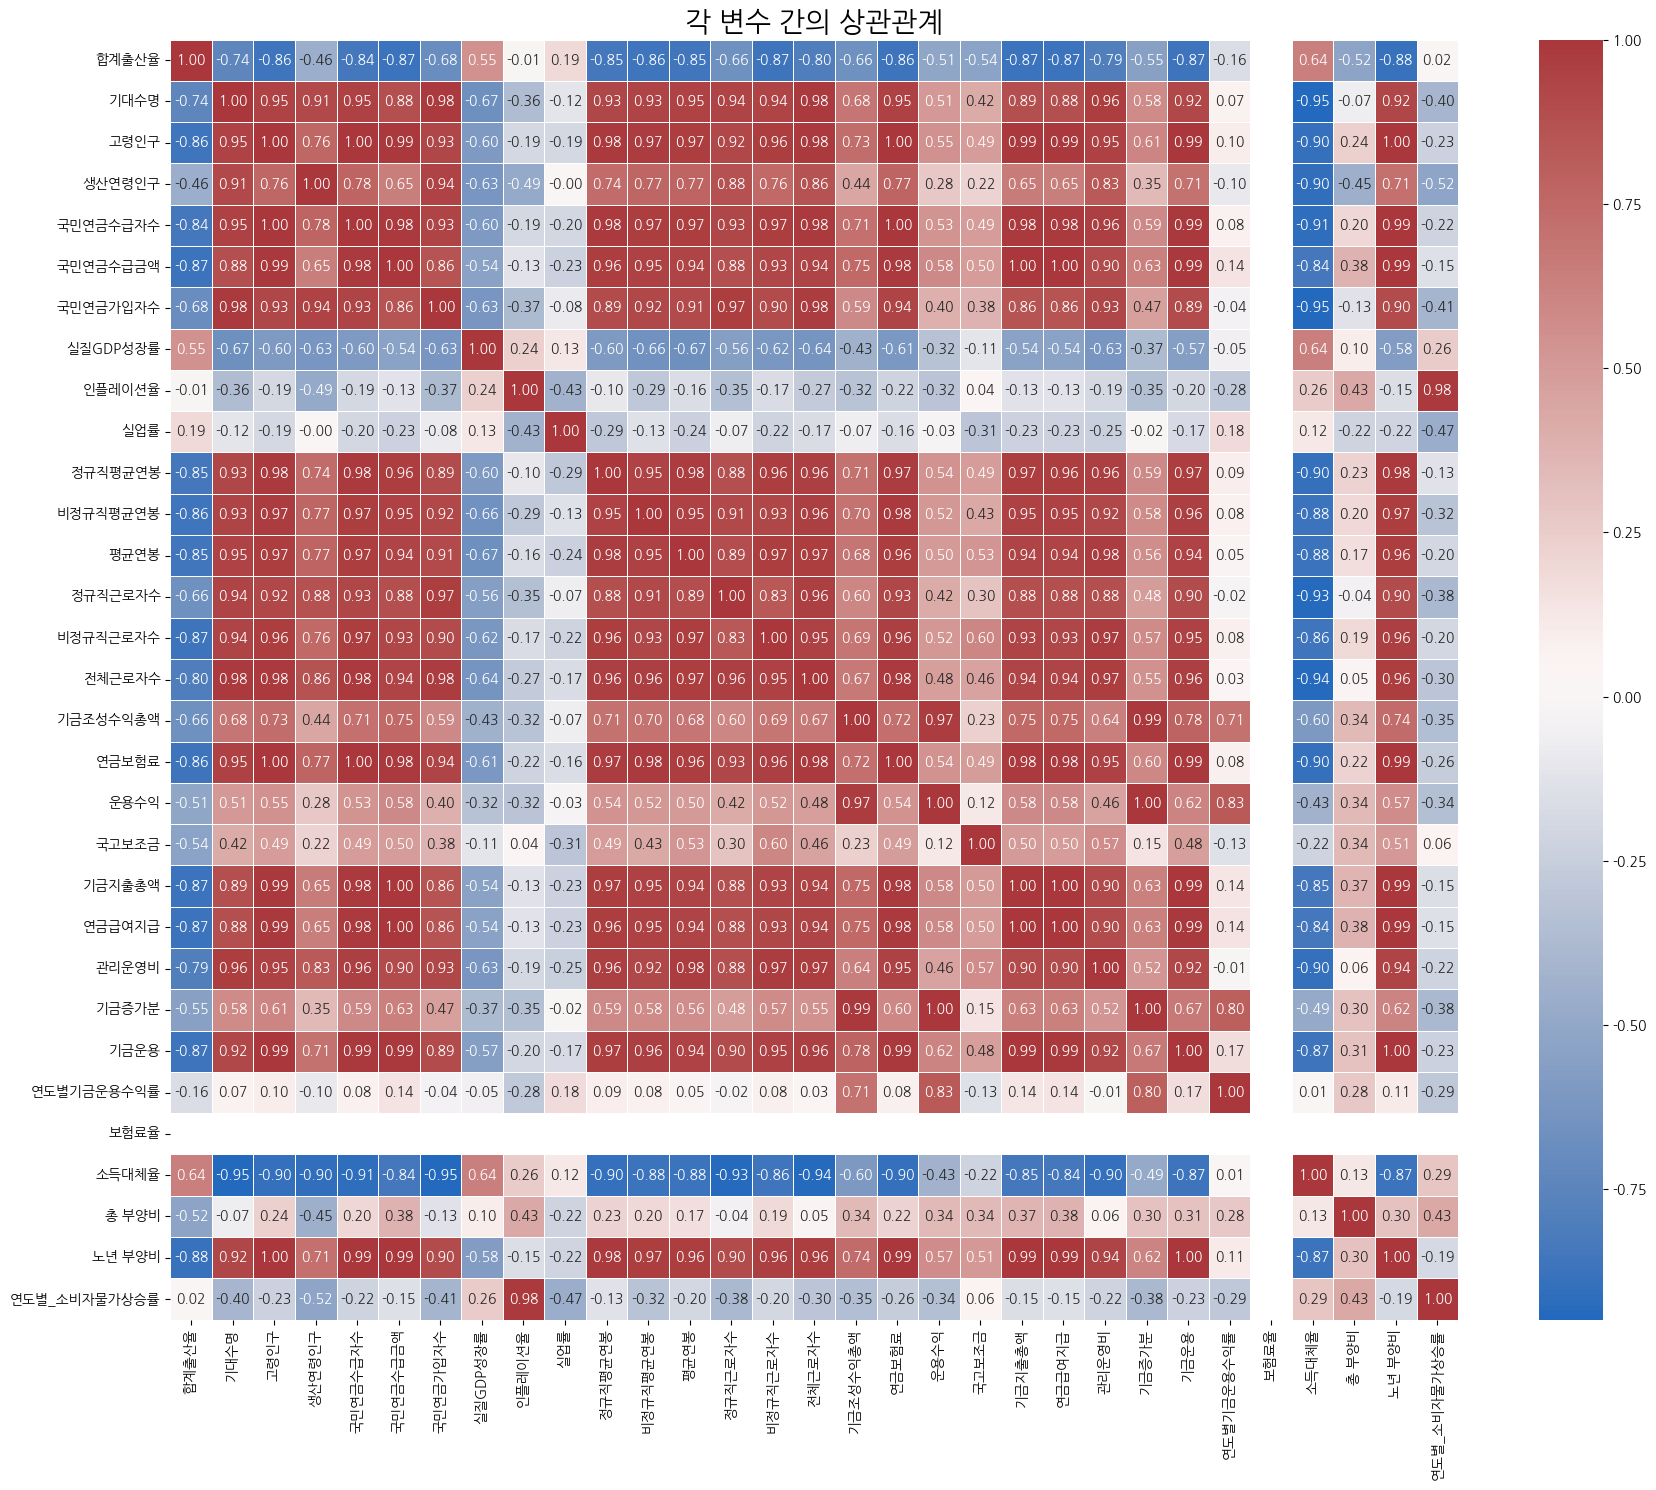

In [ ]:
# 상관계수 행렬 계산
correlation_matrix = df_scaled.corr()

# 히트맵 생성
plt.figure(figsize=(18, 15))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='vlag',
    linewidths=.5
)
plt.title('각 변수 간의 상관관계', size=20)
plt.tight_layout()
plt.show()

In [ ]:
df['수지비율'] = df['연금급여지급'] / df['연금보험료'].replace(0, np.nan)
df = df.dropna(subset=['수지비율'])

final_features_model = [
    '소득대체율',
    '합계출산율',
    '실업률',
    '연도별_소비자물가상승률'
]

y_final = df['수지비율']
X_final = df_scaled[final_features_model]
X_const = sm.add_constant(X_final)

# VIF
vif = pd.DataFrame({
    "Feature": X_const.columns,
    "VIF": [variance_inflation_factor(X_const.values, i)
            for i in range(X_const.shape[1])]
})
vif = vif[vif["Feature"] != "const"].sort_values("VIF", ascending=False)
print("최종 모델의 VIF 확인")
print(vif, "\n")

# GLSAR
model = GLSAR(y_final, X_const, rho=1)
res = model.iterative_fit(maxiter=10)
print(res.summary())

최종 모델의 VIF 확인
        Feature       VIF
1         소득대체율  2.013647
2         합계출산율  1.770581
4  연도별_소비자물가상승률  1.552636
3           실업률  1.409604 

                           GLSAR Regression Results                           
Dep. Variable:                   수지비율   R-squared:                       0.926
Model:                          GLSAR   Adj. R-squared:                  0.910
Method:                 Least Squares   F-statistic:                     59.38
Date:                Fri, 10 Oct 2025   Prob (F-statistic):           1.79e-10
Time:                        08:16:21   Log-Likelihood:                 47.464
No. Observations:                  24   AIC:                            -84.93
Df Residuals:                      19   BIC:                            -79.04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0

In [ ]:
# # 소득대체율	0.000000068395059			소득대체율이 수지비율에 미치는 영향이 우연일 확률이 1억 분의 6.2 수준으로 거의 0
# # 합계출산율	0.000139592306592			합계출산율이 수지비율에 미치는 영향이 우연일 확률이 0.012% 수준
# 실업률	0.027985502695520	유의 (P<0.05)	실업률이 수지비율에 미치는 영향이 우연일 확률이 2.7% 수준으로, 통계적으로 유의미
# 연도별소비자물가상승률	0.098744744652920	약하게 유의 (P<0.10)	연도별소비자물가상승률이 수지비율에 미치는 영향이 우연일 확률이 9.87%

#5. 미래 데이터 예측을 위한 회귀분석

컬럼명 확인: ['합계출산율(명)', '기대수명(출생시 기대여명)', '고령인구(65세 이상)', '생산연령인구 (15-64세)', '국민연금 수급자 수 (명)', '국민연금 수급자 수급금액 (단위:백만원)', '국민연급 가입자 수 (명)', '국내총생산(실질성장률) (%)', '인플레이션율 (%)', '실업률 (%)', '정규직 평균 연봉(단위: 만원, 만)', '비정규직 평균 연봉(단위: 만원, 만)', '평균 연봉(단위: 만원, 만)', '정규직 근로자 수(단위: 만원, 만)', '비정규직 근로자 수(단위: 만원, 만)', '전체 근로자 수(단위: 만원, 만)', '기금 조성(수익총액), (단위:억원)\n ; 연금보험료+운용수익+국고보조금 등 기타', '연금보험료 (단위:억원)', '운용수익 (단위:억원)', '국고보조금 등 (단위:억원)', '기금 지출총액 (단위:억원)', '연금급여지급 (단위:억원)', '관리운영비 등 (단위:억원)', '기금 증가분 (단위:억원)', '기금 운용 (단위:억원)', '연도별 기금 운용 수익률', '보험료율 (%)', '소득대체율 (%)', '총 부양비', '노년 부양비', '연도별 소비자물가상승률(%)']

▶ 평균연봉 회귀식 (차수=1)
  f(x) = 83.789*x^1 + -165993.572
  연도  평균연봉 예측값
2025   3679.62
2026   3763.41
2027   3847.20
2028   3930.99
2029   4014.78
2030   4098.57
2031   4182.36
2032   4266.14
2033   4349.93
2034   4433.72
2035   4517.51
2036   4601.30
2037   4685.09
2038   4768.88
2039   4852.67
2040   4936.46
2041   5020.25
2042   5104.04
2043   5187.83
2044   5271.62
2045   5355.40
2046   5439.19
2047   

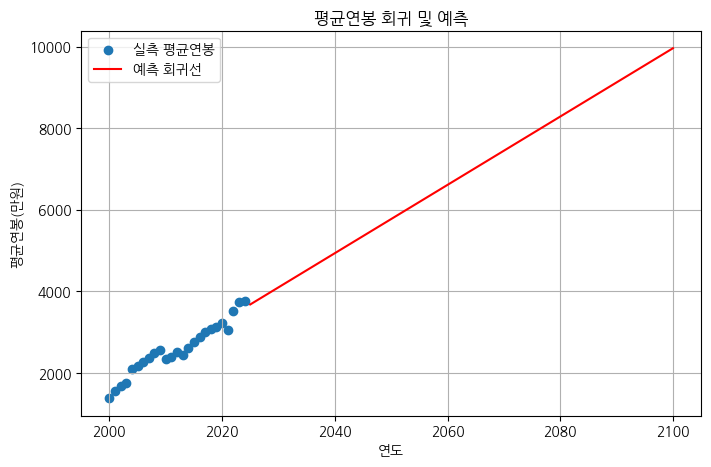

In [ ]:
df2 = pd.read_csv("통계최강자전.csv", encoding="utf-8-sig", index_col=0)
df2.index.name = "연도"

# 컬럼명 확인
print("컬럼명 확인:", df2.columns.tolist())
# 2. 필요한 열 추출 (쉼표 제거 후 숫자로 변환)
years = df2.index.values.astype(int)

avg_wage = df2["평균 연봉(단위: 만원, 만)"].astype(float).values

contributors = df2["국민연급 가입자 수 (명)"].str.replace(",", "").astype(float).values
beneficiaries = df2["국민연금 수급자 수 (명)"].str.replace(",", "").astype(float).values
contrib_income = df2["연금보험료 (단위:억원)"].str.replace(",", "").astype(float).values
benefit_outgo = df2["연금급여지급 (단위:억원)"].str.replace(",", "").astype(float).values



# 3. 회귀 적합 및 예측 함수 정의
def fit_and_predict(x, y, degree, name, start_year=2025, end_year=2100):
    coef = np.polyfit(x, y, degree)
    poly = np.poly1d(coef)

    # 회귀식 출력
    print(f"\n▶ {name} 회귀식 (차수={degree})")
    eqn = " + ".join(
        [f"{round(c,3)}*x^{deg}" if deg > 0 else f"{round(c,3)}"
         for deg, c in zip(range(degree, -1, -1), coef)]
    )
    print("  f(x) =", eqn)

    # 예측
    pred_years = np.arange(start_year, end_year+1)
    pred_values = poly(pred_years)
    result = pd.DataFrame({"연도": pred_years, f"{name} 예측값": np.round(pred_values, 2)})
    print(result.to_string(index=False))

    return poly, result

# 4. 각 변수별 회귀 적합 및 예측
poly_avg, pred_avg = fit_and_predict(years, avg_wage, 1, "평균연봉")            # 선형
poly_contrib, pred_contrib = fit_and_predict(years, contributors, 2, "가입자수") # 2차
poly_benef, pred_benef = fit_and_predict(years, beneficiaries, 2, "수급자수")   # 2차
poly_income, pred_income = fit_and_predict(years, contrib_income, 2, "연금보험료") # 2차
poly_outgo, pred_outgo = fit_and_predict(years, benefit_outgo, 3, "연금급여지급") # 3차

# 5. 시각화 (평균연봉 예시)
plt.figure(figsize=(8,5))
plt.scatter(years, avg_wage, label="실측 평균연봉")
plt.plot(pred_avg["연도"], pred_avg["평균연봉 예측값"], color="red", label="예측 회귀선")
plt.title("평균연봉 회귀 및 예측")
plt.xlabel("연도"); plt.ylabel("평균연봉(만원)")
plt.legend(); plt.grid(True); plt.show()

#6. 기금 고갈 시점 예측 모델 생성

In [ ]:
# 1. CSV 불러오기
df = pd.read_csv("통계최강자전.csv", encoding="utf-8-sig", index_col=0)
df.index.name = "연도"

# 2. 필요한 열 추출 (쉼표 제거 후 숫자 변환)
years = df.index.values.astype(int)
avg_wage = df["평균 연봉(단위: 만원, 만)"].astype(float).values
contributors = df["국민연급 가입자 수 (명)"].str.replace(",", "").astype(float).values
beneficiaries = df["국민연금 수급자 수 (명)"].str.replace(",", "").astype(float).values
contrib_income = df["연금보험료 (단위:억원)"].str.replace(",", "").astype(float).values
benefit_outgo = df["연금급여지급 (단위:억원)"].str.replace(",", "").astype(float).values

##현재 체제로의 보험료율 변화에 따른 시나리오

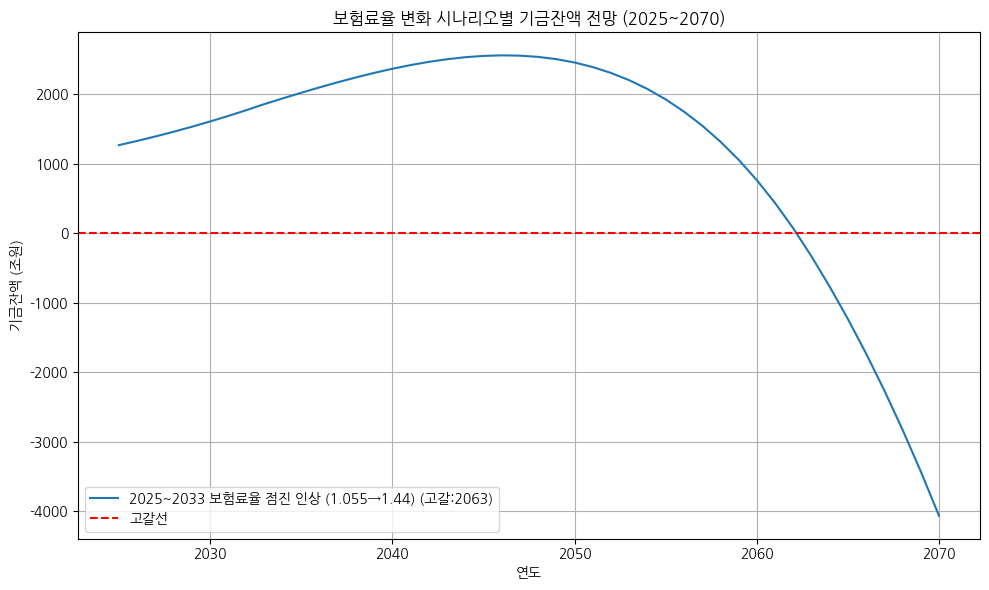

각 시나리오 고갈 예상 연도 (2070년 기준): [2063]


In [ ]:
# 데이터 로드 및 전처리 함수
def load_and_clean(path, encoding="utf-8-sig"):
    df = pd.read_csv(path, encoding=encoding, index_col=0)
    df.index.name = "연도"
    def clean_col(s):
        return s.astype(str).str.replace(",", "").astype(float)
    df["연금보험료 (단위:억원)"] = clean_col(df["연금보험료 (단위:억원)"])
    df["연금급여지급 (단위:억원)"] = clean_col(df["연금급여지급 (단위:억원)"])
    return df

# 수입 및 지출 모델 적합 함수
def fit_income_outgo_models(df, deg_income=2, deg_outgo=3):
    years = df.index.values.astype(int)
    income = df["연금보험료 (단위:억원)"].values
    outgo = df["연금급여지급 (단위:억원)"].values
    coef_i = np.polyfit(years, income, deg_income)
    coef_o = np.polyfit(years, outgo, deg_outgo)
    model_i = np.poly1d(coef_i)
    model_o = np.poly1d(coef_o)
    return model_i, model_o

# 보험료율 함수 (2025년 1.055, 2026년부터 매년 0.055씩 증가, 2033년 이후 1.44로 고정)
def insurance_rate_fn(yr):
    if yr < 2025:
        return 1.0  # 2024년까지는 1.0
    elif yr <= 2033:
        return 1.055 + 0.055 * (yr - 2025)  # 2025년 1.055, 2026년 1.11, ..., 2033년 1.44
    else:
        return 1.44  # 2034년 이후는 1.44로 고정

# 시뮬레이션 함수
def simulate_with_rate_change(model_income, model_outgo,
                              base_balance,
                              start_year=2025, end_year=2070,
                              admin_rate=0.02,
                              invest_rate=0.03,
                              insurance_rate_fn=None):
    years = np.arange(start_year, end_year + 1)
    balance = base_balance
    balances = []
    for yr in years:
        inc0 = model_income(yr)
        rate_mult = insurance_rate_fn(yr) if insurance_rate_fn is not None else 1.0
        income = inc0 * rate_mult

        outgo = model_outgo(yr)
        admin = admin_rate * outgo
        invest = balance * invest_rate if balance > 0 else 0
        balance = balance + income + invest - (outgo + admin)
        balances.append(balance)

    df = pd.DataFrame({
        "연도": years,
        "잔액(억원)": balances
    })
    df["잔액(조원)"] = df["잔액(억원)"] / 10000.0
    return df

# 고갈 연도 찾기 함수
def find_exhaustion_year(df_fund):
    neg = df_fund[df_fund["잔액(억원)"] < 0]
    if neg.empty:
        return None
    return int(neg.iloc[0]["연도"])

# 시나리오 비교 함수
def compare_rate_scenarios(df, base_balance, admin_rate, invest_rate,
                           rate_scenarios, labels=None,
                           deg_income=2, deg_outgo=3,
                           start_year=2025, end_year=2070):
    model_i, model_o = fit_income_outgo_models(df, deg_income, deg_outgo)
    plt.figure(figsize=(10,6))
    exhaustion = []
    for idx, scenario in enumerate(rate_scenarios):
        label = labels[idx] if labels else f"rate_scenario_{idx}"
        insurance_rate_fn = scenario.get("fn", None)
        df_sim = simulate_with_rate_change(model_i, model_o,
                                          base_balance=base_balance,
                                          start_year=start_year,
                                          end_year=end_year,
                                          admin_rate=admin_rate,
                                          invest_rate=invest_rate,
                                          insurance_rate_fn=insurance_rate_fn)
        ex = find_exhaustion_year(df_sim)
        exhaustion.append(ex)
        plt.plot(df_sim["연도"], df_sim["잔액(조원)"], label=f"{label} (고갈:{ex})")

    plt.axhline(0, color="red", linestyle="--", label="고갈선")
    plt.xlabel("연도")
    plt.ylabel("기금잔액 (조원)")
    plt.title(f"보험료율 변화 시나리오별 기금잔액 전망 ({start_year}~{end_year})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return exhaustion

if __name__ == "__main__":
    df = load_and_clean("통계최강자전.csv")
    base_balance = 12128513  # 억 원
    admin_rate = 0.02
    invest_rate = 0.03

    rate_scenarios = [
        {"fn": insurance_rate_fn}  # 2025년 1.055, 2026년부터 매년 0.055씩 증가, 2033년 1.44로 고정
    ]
    labels = ["2025~2033 보험료율 점진 인상 (1.055→1.44)"]

    ex_years = compare_rate_scenarios(df, base_balance, admin_rate, invest_rate,
                                      rate_scenarios, labels,
                                      deg_income=2, deg_outgo=3,
                                      start_year=2025, end_year=2070)
    print("각 시나리오 고갈 예상 연도 (2070년 기준):", ex_years)

##정책 변화 전과 후 기금 고갈 시점 비교

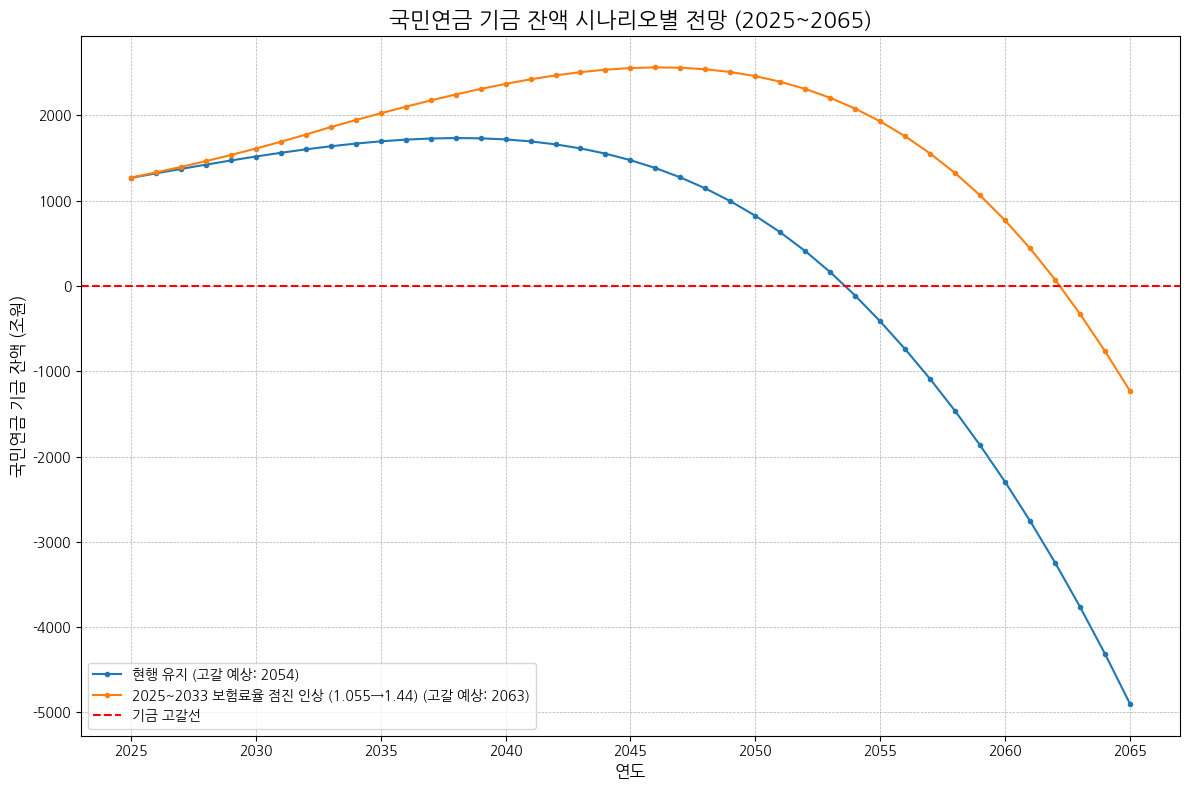

시뮬레이션 시작 연도: 2025
2024년 기준 기금 잔액: 약 1,212.85 조원

각 시나리오별 고갈 예상 연도:
- 현행 유지: 2054
- 2025~2033 보험료율 점진 인상 (1.055→1.44): 2063


In [ ]:
# 1. 데이터 로드 및 전처리
try:
    # CSV 파일을 읽어들입니다. 한글 파일명을 위해 encoding을 지정합니다.
    df_original = pd.read_csv("통계최강자전.csv", encoding="utf-8-sig", index_col=0)
    df_original.index.name = "연도"
except FileNotFoundError:
    print("오류: '통계최강자전.csv' 파일을 찾을 수 없습니다. 스크립트와 같은 디렉토리에 있는지 확인하세요.")
    exit()
except Exception as e:
    print(f"파일을 읽는 중 오류가 발생했습니다: {e}")
    exit()


# 필요한 열의 쉼표를 제거하고 숫자로 변환하는 함수
def clean_numeric_column(series):
    return series.astype(str).str.replace(",", "").astype(float)

# 데이터 클리닝
columns_to_clean = [
    "국민연금 수급자 수 (명)", "국민연급 가입자 수 (명)", "연금보험료 (단위:억원)",
    "연금급여지급 (단위:억원)", "기금 운용 (단위:억원)"
]
for col in columns_to_clean:
    if col in df_original.columns:
        df_original[col] = clean_numeric_column(df_original[col])
    else:
        # '국민연급 가입자 수 (명)'과 같이 오타가 있을 수 있는 컬럼에 대한 처리
        # 유사한 컬럼명을 찾아 처리할 수도 있으나, 여기서는 경고만 출력합니다.
        print(f"경고: '{col}' 열을 원본 데이터에서 찾을 수 없습니다.")


# 2. 회귀 모델을 사용한 미래 데이터 생성
def fit_and_predict_future(x_hist, y_hist, degree, future_years):
    """주어진 데이터로 다항 회귀 모델을 적합하고 미래 값을 예측합니다."""
    coef = np.polyfit(x_hist, y_hist, degree)
    poly_model = np.poly1d(coef)
    predicted_values = poly_model(future_years)
    return predicted_values

# 예측 기간 설정
last_year_in_data = df_original.index.max()
prediction_start_year = last_year_in_data + 1
prediction_end_year = 2100
future_years = np.arange(prediction_start_year, prediction_end_year + 1)

# historical data 추출
years_hist = df_original.index.values
income_hist = df_original["연금보험료 (단위:억원)"].values
outgo_hist = df_original["연금급여지급 (단위:억원)"].values

# 미래 수입 및 지출 예측 (수입=2차, 지출=3차 다항 회귀)
predicted_income = fit_and_predict_future(years_hist, income_hist, 2, future_years)
predicted_outgo = fit_and_predict_future(years_hist, outgo_hist, 3, future_years)

# 예측 데이터프레임 생성
df_predicted = pd.DataFrame({
    "연도": future_years,
    "연금보험료 (단위:억원)": predicted_income,
    "연금급여지급 (단위:억원)": predicted_outgo
}).set_index("연도")


# 3. 과거 데이터와 예측 데이터 결합
df_combined = pd.concat([
    df_original[["연금보험료 (단위:억원)", "연금급여지급 (단위:억원)"]],
    df_predicted
])


# 4. 시뮬레이션 관련 함수 정의

# 보험료율 함수
def insurance_rate_fn(yr):
    if yr < 2025:
        return 1.0
    elif yr <= 2033:
        return 1.0 + 0.055 * (yr - 2024)
    else:
        return 1.44

# 시뮬레이션 함수
def simulate_with_rate_change(data, base_balance, start_year, end_year,
                              admin_rate=0.02, invest_rate=0.03,
                              insurance_rate_fn=None):
    simulation_years = np.arange(start_year, end_year + 1)
    balance = base_balance
    balances = []

    for yr in simulation_years:
        inc0 = data.loc[yr, "연금보험료 (단위:억원)"]
        outgo = data.loc[yr, "연금급여지급 (단위:억원)"]

        rate_multiplier = insurance_rate_fn(yr) if insurance_rate_fn else 1.0
        income = inc0 * rate_multiplier

        admin_cost = admin_rate * outgo
        investment_return = balance * invest_rate if balance > 0 else 0

        balance += income + investment_return - (outgo + admin_cost)
        balances.append(balance)

    df_result = pd.DataFrame({
        "연도": simulation_years,
        "잔액(억원)": balances
    })
    df_result["잔액(조원)"] = df_result["잔액(억원)"] / 10000.0
    return df_result

# 고갈 연도 찾기 함수
def find_exhaustion_year(df_fund):
    neg_balance_years = df_fund[df_fund["잔액(억원)"] < 0]
    if neg_balance_years.empty:
        return "고갈되지 않음"
    return int(neg_balance_years.iloc[0]["연도"])


# 5. 시뮬레이션 실행

# 시뮬레이션 파라미터 설정
base_balance_2024 = df_original.loc[last_year_in_data, "기금 운용 (단위:억원)"]
simulation_start_year = 2025
simulation_end_year = 2065
admin_rate = 0.02
invest_rate = 0.03

# 시나리오 설정
scenarios = [
    {"fn": None, "label": "현행 유지"},
    {"fn": insurance_rate_fn, "label": "2025~2033 보험료율 점진 인상 (1.055→1.44)"}
]

# 시뮬레이션 및 시각화
plt.figure(figsize=(12, 8))
exhaustion_results = {}

for scenario in scenarios:
    df_simulation = simulate_with_rate_change(
        data=df_combined,
        base_balance=base_balance_2024,
        start_year=simulation_start_year,
        end_year=simulation_end_year,
        admin_rate=admin_rate,
        invest_rate=invest_rate,
        insurance_rate_fn=scenario["fn"]
    )

    exhaustion_year = find_exhaustion_year(df_simulation)
    exhaustion_results[scenario["label"]] = exhaustion_year

    label_text = f"{scenario['label']} (고갈 예상: {exhaustion_year})"
    plt.plot(df_simulation["연도"], df_simulation["잔액(조원)"], label=label_text, marker='o', markersize=3, linestyle='-')

# 그래프 설정
plt.axhline(0, color="red", linestyle="--", linewidth=1.5, label="기금 고갈선")
plt.xlabel("연도", fontsize=12)
plt.ylabel("국민연금 기금 잔액 (조원)", fontsize=12)
plt.title(f"국민연금 기금 잔액 시나리오별 전망 ({simulation_start_year}~{simulation_end_year})", fontsize=16)
plt.legend(fontsize=10)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("pension_simulation_2100.png")
plt.show()

# 결과 출력
print(f"시뮬레이션 시작 연도: {simulation_start_year}")
print(f"2024년 기준 기금 잔액: 약 {base_balance_2024 / 10000:,.2f} 조원")
print("\n각 시나리오별 고갈 예상 연도:")
for label, year in exhaustion_results.items():
    print(f"- {label}: {year}")

##고정 변수로 기금 수익률 설정 후 기금 고갈 시점 예측

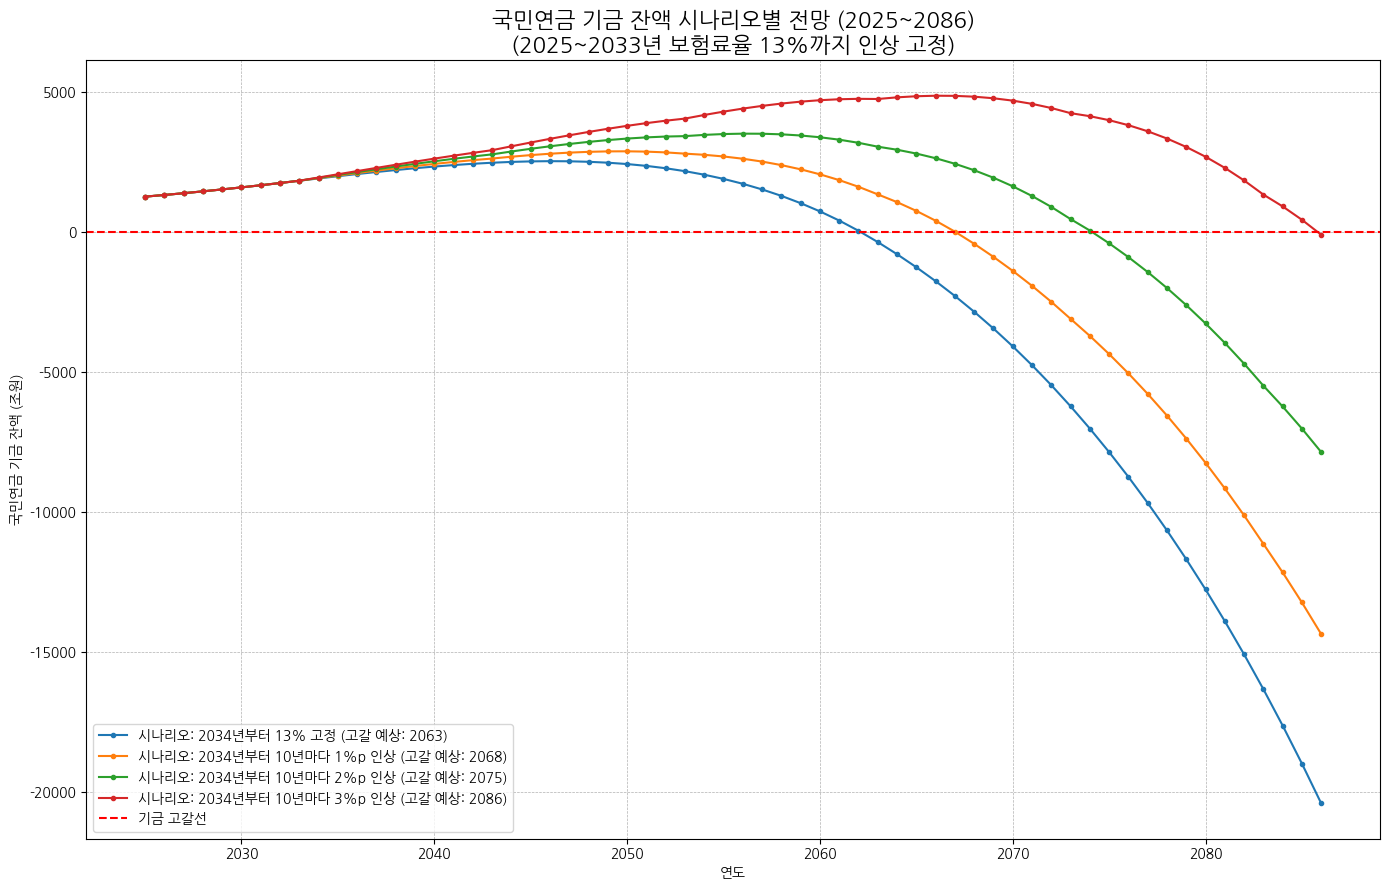

시뮬레이션 시작 연도: 2025
2024년 기준 기금 잔액: 약 1,212.85 조원

각 시나리오별 고갈 예상 연도:
- 2034년부터 13% 고정: 2063
- 2034년부터 10년마다 1%p 인상: 2068
- 2034년부터 10년마다 2%p 인상: 2075
- 2034년부터 10년마다 3%p 인상: 2086


In [ ]:
df_original = pd.read_csv("통계최강자전.csv", encoding="utf-8-sig", index_col=0)
df_original.index.name = "연도"

def clean_numeric_column(series):
    return series.astype(str).str.replace(",", "").astype(float)

# 데이터 클리닝
for col in ["연금보험료 (단위:억원)", "연금급여지급 (단위:억원)", "기금 운용 (단위:억원)"]:
    if col in df_original.columns:
        df_original[col] = clean_numeric_column(df_original[col])

# 2. 회귀 모델을 사용한 미래 데이터 생성
def fit_and_predict_future(x_hist, y_hist, degree, future_years):
    coef = np.polyfit(x_hist, y_hist, degree)
    poly_model = np.poly1d(coef)
    return poly_model(future_years)

last_year_in_data = df_original.index.max()
future_years = np.arange(last_year_in_data + 1, 2101)
years_hist = df_original.index.values

predicted_income = fit_and_predict_future(years_hist, df_original["연금보험료 (단위:억원)"].values, 2, future_years)
predicted_outgo = fit_and_predict_future(years_hist, df_original["연금급여지급 (단위:억원)"].values, 3, future_years)

df_predicted = pd.DataFrame({
    "연금보험료 (단위:억원)": predicted_income,
    "연금급여지급 (단위:억원)": predicted_outgo
}, index=future_years)
df_predicted.index.name = "연도"

df_combined = pd.concat([
    df_original[["연금보험료 (단위:억원)", "연금급여지급 (단위:억원)"]],
    df_predicted
])

# 3. 새로운 시나리오 함수 정의
BASE_RATE = 9.0

def get_ramp_up_multiplier(yr):
    """2025년부터 2033년까지 9%에서 13%로 선형 증가하는 승수 계산 (모든 시나리오 공통)"""
    target_rate = 13.0
    years_for_ramp_up = 2033 - 2024
    current_rate = BASE_RATE + (target_rate - BASE_RATE) * (yr - 2024) / years_for_ramp_up
    return current_rate / BASE_RATE

# 시나리오 1: 2034년부터 13% 고정
def rate_scenario1_fn(yr):
    if yr <= 2033:
        return get_ramp_up_multiplier(yr)
    else:
        return 13.0 / BASE_RATE

# 시나리오 2: 2034년부터 10년마다 1%p 증가
def rate_scenario2_fn(yr):
    if yr <= 2033:
        return get_ramp_up_multiplier(yr)
    else:
        rate_at_2033 = 13.0
        decades_passed = (yr - 2034) // 10
        current_rate = rate_at_2033 + (decades_passed + 1) * 1.0
        return current_rate / BASE_RATE

# 시나리오 3: 2034년부터 10년마다 2%p 증가
def rate_scenario3_fn(yr):
    if yr <= 2033:
        return get_ramp_up_multiplier(yr)
    else:
        rate_at_2033 = 13.0
        decades_passed = (yr - 2034) // 10
        current_rate = rate_at_2033 + (decades_passed + 1) * 2.0
        return current_rate / BASE_RATE

# 시나리오 4: 2034년부터 10년마다 3%p 증가 (추가)
def rate_scenario4_fn(yr):
    if yr <= 2033:
        return get_ramp_up_multiplier(yr)
    else:
        rate_at_2033 = 13.0
        decades_passed = (yr - 2034) // 10
        current_rate = rate_at_2033 + (decades_passed + 1) * 3.0
        return current_rate / BASE_RATE

# 4. 시뮬레이션 함수
def simulate(data, base_balance, start_year, end_year, insurance_rate_fn, admin_rate=0.02, invest_rate=0.03):
    years = np.arange(start_year, end_year + 1)
    balance = base_balance
    balances = []
    for yr in years:
        investment_return = balance * invest_rate if balance > 0 else 0
        balance += investment_return

        inc0 = data.loc[yr, "연금보험료 (단위:억원)"]
        outgo = data.loc[yr, "연금급여지급 (단위:억원)"]

        rate_multiplier = insurance_rate_fn(yr)
        income = inc0 * rate_multiplier
        admin_cost = outgo * admin_rate

        balance += income - (outgo + admin_cost)
        balances.append(balance)

    df_result = pd.DataFrame({"연도": years, "잔액(억원)": balances})
    df_result["잔액(조원)"] = df_result["잔액(억원)"] / 10000.0
    return df_result

def find_exhaustion_year(df_fund):
    neg_balance_years = df_fund[df_fund["잔액(억원)"] < 0]
    return int(neg_balance_years.iloc[0]["연도"]) if not neg_balance_years.empty else "고갈되지 않음"

# 5. 시뮬레이션 실행 및 시각화
base_balance_2024 = df_original.loc[last_year_in_data, "기금 운용 (단위:억원)"]
start_year, end_year = 2025, 2086

scenarios = [
    {"fn": rate_scenario1_fn, "label": "2034년부터 13% 고정"},
    {"fn": rate_scenario2_fn, "label": "2034년부터 10년마다 1%p 인상"},
    {"fn": rate_scenario3_fn, "label": "2034년부터 10년마다 2%p 인상"},
    {"fn": rate_scenario4_fn, "label": "2034년부터 10년마다 3%p 인상"}
]

plt.figure(figsize=(14, 9))
exhaustion_results = {}

for scenario in scenarios:
    df_sim = simulate(df_combined, base_balance_2024, start_year, end_year, scenario["fn"])
    ex_year = find_exhaustion_year(df_sim)
    exhaustion_results[scenario["label"]] = ex_year
    label = f"시나리오: {scenario['label']} (고갈 예상: {ex_year})"
    plt.plot(df_sim["연도"], df_sim["잔액(조원)"], label=label, marker='o', markersize=3)

plt.axhline(0, color="red", linestyle="--", linewidth=1.5, label="기금 고갈선")
plt.xlabel("연도")
plt.ylabel("국민연금 기금 잔액 (조원)")
plt.title(f"국민연금 기금 잔액 시나리오별 전망 ({start_year}~{end_year})\n(2025~2033년 보험료율 13%까지 인상 고정)", fontsize=16)
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("pension_simulation_all_scenarios.png")
plt.show()

print(f"시뮬레이션 시작 연도: {start_year}")
print(f"2024년 기준 기금 잔액: 약 {base_balance_2024 / 10000:,.2f} 조원")
print("\n각 시나리오별 고갈 예상 연도:")
for label, year in exhaustion_results.items():
    print(f"- {label}: {year}")

## 현 체제 내에서 기금 수익률에 따른 기금 고갈 시점 예측

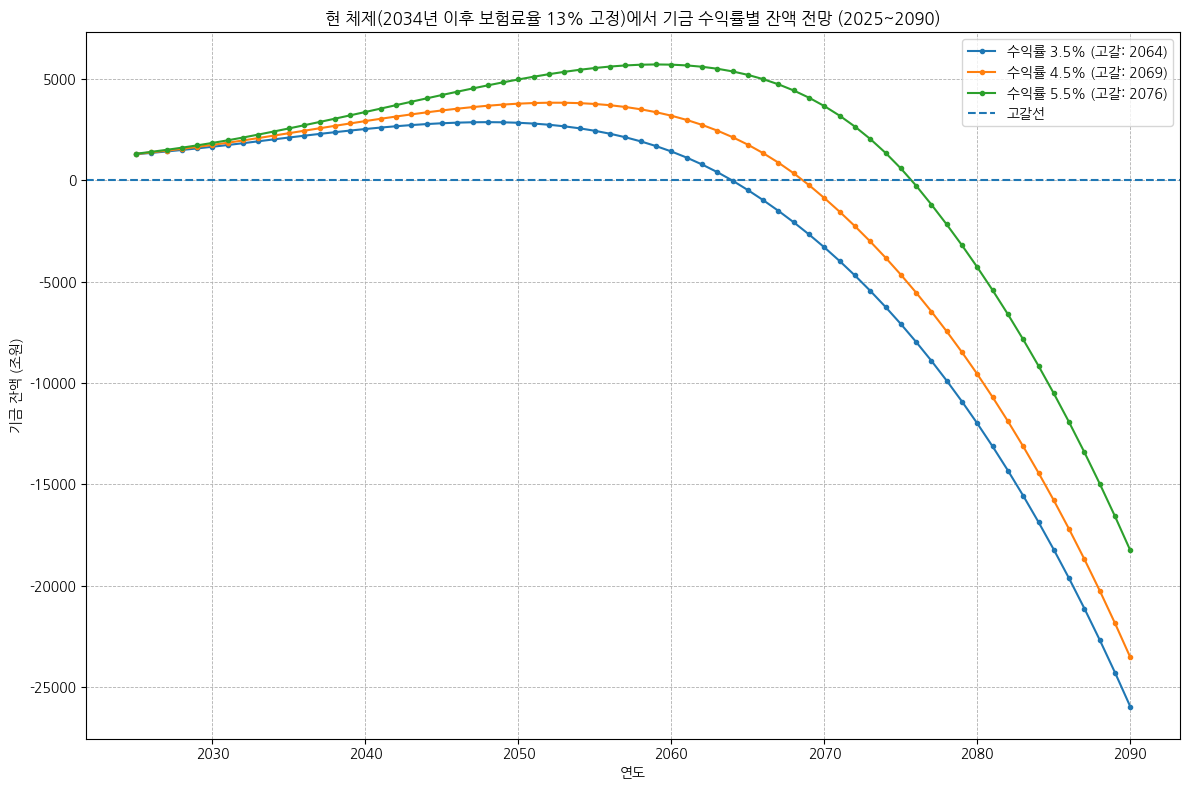

[기준연도] 2024
[2024년 기준 기금 잔액(명목)] 약 1,212.85 조원

[수익률 시나리오별 고갈 예상 연도]
- 수익률 3.5%: 2064
- 수익률 4.5%: 2069
- 수익률 5.5%: 2076


In [ ]:
"""
현 체제 가정:
- 보험료율: 2025~2033년까지 9% → 13% 선형 증가(승수), 2034년 이후 13% 고정
- 관리·운영비: 급여의 2% (모형 가정)
- 기금 수익률(명목): 3가지 시나리오 3.5%, 4.5%, 5.5%
- 시뮬레이션 기간: 2025~2090
- 출력: 수익률 3가지 곡선을 한 그래프에 표시 + 각 시나리오 고갈연도 출력
"""

# 1) 데이터 로드/전처리
def load_and_clean(path, encoding="utf-8-sig"):
    df = pd.read_csv(path, encoding=encoding, index_col=0)
    df.index.name = "연도"
    df.index = df.index.astype(int)

    def clean_col(s):
        return (
            s.astype(str)
             .str.replace(",", "", regex=False)
             .str.replace(" ", "", regex=False)
             .str.replace("\u00a0", "", regex=False)
             .replace({"": np.nan})
             .astype(float)
        )

    # 필수 열 클리닝
    for col in ["연금보험료 (단위:억원)", "연금급여지급 (단위:억원)"]:
        if col not in df.columns:
            raise KeyError(f"필수 컬럼 없음: {col}")
        df[col] = clean_col(df[col])

    # 선택 열: 기금 운용(잔액)
    if "기금 운용 (단위:억원)" in df.columns:
        df["기금 운용 (단위:억원)"] = clean_col(df["기금 운용 (단위:억원)"])

    return df

# =========================
# 2) 외삽 모델(다항 회귀)
# =========================
def fit_income_outgo_models(df, deg_income=2, deg_outgo=3):
    years = df.index.values.astype(int)
    income = df["연금보험료 (단위:억원)"].values
    outgo = df["연금급여지급 (단위:억원)"].values
    coef_i = np.polyfit(years, income, deg_income)
    coef_o = np.polyfit(years, outgo, deg_outgo)
    return np.poly1d(coef_i), np.poly1d(coef_o)

# =========================
# 3) 보험료율 멀티플라이어(2025~2033 선형 → 13% 고정)
# =========================
BASE_RATE = 9.0
TARGET_RATE = 13.0

def insurance_rate_multiplier(yr):
    """
    - 2024년까지: 1.0
    - 2025~2033: 9%→13% 선형 증가(2033년에 13% 도달)
    - 2034년 이후: 13% 고정
    """
    if yr <= 2024:
        return 1.0
    elif yr <= 2033:
        years_for_ramp = 2033 - 2024  # 9년(2025~2033)
        current = BASE_RATE + (TARGET_RATE - BASE_RATE) * (yr - 2024) / years_for_ramp
        return current / BASE_RATE
    else:
        return TARGET_RATE / BASE_RATE

# =========================
# 4) 시뮬레이션
# =========================
def simulate_with_invest_rate(model_income, model_outgo,
                              base_balance,
                              start_year=2025, end_year=2090,
                              admin_rate=0.02,
                              invest_rate=0.035):
    years = np.arange(start_year, end_year + 1)
    balance = float(base_balance)
    balances = []

    for yr in years:
        # 외삽값(음수 방지)
        inc0 = max(0.0, float(model_income(yr)))
        out0 = max(0.0, float(model_outgo(yr)))

        # 보험료율 멀티플라이어
        rate_mult = insurance_rate_multiplier(yr)
        income = inc0 * rate_mult

        # 운영비(급여의 2%)
        admin = admin_rate * out0

        # 운용수익(명목), 음수 잔액은 수익 0으로 처리
        invest = balance * invest_rate if balance > 0 else 0.0

        # 잔액 갱신
        balance = balance + income + invest - (out0 + admin)
        balances.append(balance)

    df = pd.DataFrame({"연도": years, "잔액(억원)": balances})
    df["잔액(조원)"] = df["잔액(억원)"] / 10000.0
    return df

def find_exhaustion_year(df_fund):
    neg = df_fund[df_fund["잔액(억원)"] < 0]
    return int(neg.iloc[0]["연도"]) if not neg.empty else "고갈되지 않음"

# =========================
# 5) 실행: 수익률 3가지(3.5, 4.5, 5.5%) × 단일 보험료율 정책
# =========================
def main():
    # CSV 로드
    df = load_and_clean("통계최강자전.csv")

    # 베이스 잔액(가능하면 CSV에서, 없으면 보수적 예시값 사용)
    if "기금 운용 (단위:억원)" in df.columns:
        base_balance = float(df.loc[df.index.max(), "기금 운용 (단위:억원)"])
    else:
        # 필요시 사용자가 최신 잔액으로 교체
        base_balance = 12128513.0  # 억원 (예시)

    # 외삽 모델
    model_i, model_o = fit_income_outgo_models(df, deg_income=2, deg_outgo=3)

    # 수익률 시나리오
    invest_rates = [0.035, 0.045, 0.055]
    labels = ["수익률 3.5%", "수익률 4.5%", "수익률 5.5%"]

    start_year, end_year = 2025, 2090

    # 그래프
    plt.figure(figsize=(12, 8))
    exhaustion_list = []

    for ir, label in zip(invest_rates, labels):
        df_sim = simulate_with_invest_rate(
            model_i, model_o,
            base_balance=base_balance,
            start_year=start_year, end_year=end_year,
            admin_rate=0.02,
            invest_rate=ir
        )
        ex_year = find_exhaustion_year(df_sim)
        exhaustion_list.append((label, ex_year))
        plt.plot(df_sim["연도"], df_sim["잔액(조원)"], label=f"{label} (고갈: {ex_year})", marker="o", markersize=3)

    plt.axhline(0, linestyle="--", linewidth=1.5, label="고갈선")
    plt.xlabel("연도")
    plt.ylabel("기금 잔액 (조원)")
    plt.title(f"현 체제(2034년 이후 보험료율 13% 고정)에서 기금 수익률별 잔액 전망 ({start_year}~{end_year})")
    plt.legend()
    plt.grid(True, linestyle="--", linewidth=0.6)
    plt.tight_layout()

    out_png = "pension_exhaustion_2025_2090_by_invest_rate.png"
    plt.savefig(out_png, dpi=150)
    plt.show()

    # 결과 요약 출력
    print(f"[기준연도] {df.index.max()}")
    if "기금 운용 (단위:억원)" in df.columns:
        print(f"[{df.index.max()}년 기준 기금 잔액(명목)] 약 {base_balance/10000:,.2f} 조원")
    print("\n[수익률 시나리오별 고갈 예상 연도]")
    for label, ex in exhaustion_list:
        print(f"- {label}: {ex}")

if __name__ == "__main__":
    main()

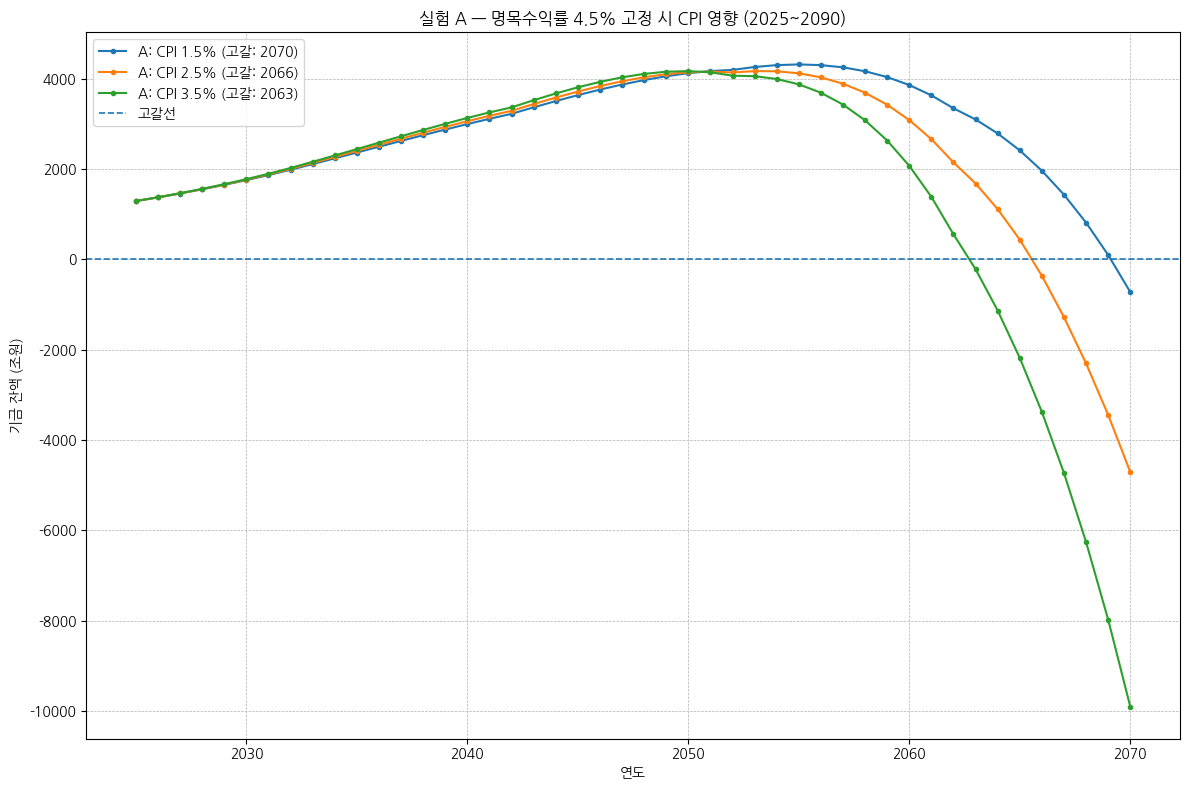

[실험 A] CPI별 고갈 연도:
 - CPI 1.5%: 2070
 - CPI 2.5%: 2066
 - CPI 3.5%: 2063


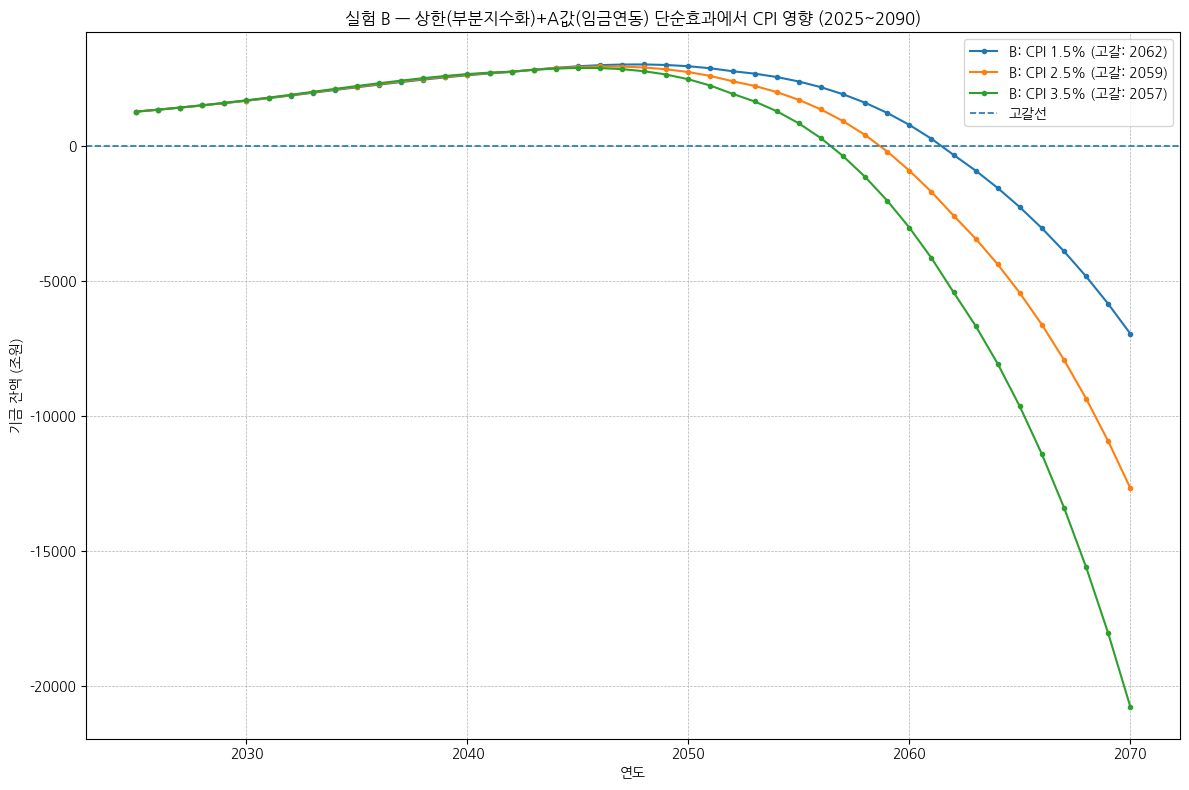


[실험 B] CPI별 고갈 연도 (가정: g_real_w=1%, 상한은 CPI의 80%만 반영 등):
 - CPI 1.5%: 2062
 - CPI 2.5%: 2059
 - CPI 3.5%: 2057


In [ ]:
# -*- coding: utf-8 -*-
"""
실험 A: 명목수익률(i) 고정 후 CPI(1.5/2.5/3.5%) 비교
실험 B: 상한(부분지수화) + 임금연동(A값) 효과의 단순화 → CPI와 상호작용을 관찰
- 보험료율: 2025~2033 9%→13% 선형 인상, 2033 기준 10년마다 +2%p
- 운영비: 급여의 2%
- 기간: 2025~2090
- 입력 CSV: 통계최강자전.csv (index=연도, 열: '연금보험료 (단위:억원)', '연금급여지급 (단위:억원)', '기금 운용 (단위:억원)'(선택))
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ===== (선택) 한글 폰트 =====
def try_set_korean_font():
    from matplotlib import font_manager, rcParams
    cands = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR", "나눔고딕"]
    avail = {f.name for f in font_manager.fontManager.ttflist}
    for name in cands:
        if name in avail:
            rcParams["font.family"] = name
            rcParams["axes.unicode_minus"] = False
            break
try:
    try_set_korean_font()
except Exception:
    pass

# ===== 1) 데이터 로드/전처리 =====
def load_and_clean(path="통계최강자전.csv", encoding="utf-8-sig"):
    df = pd.read_csv(path, encoding=encoding, index_col=0)
    df.index.name = "연도"
    df.index = df.index.astype(int)
    def clean(s):
        return (
            s.astype(str)
             .str.replace(",", "", regex=False)
             .str.replace(" ", "", regex=False)
             .str.replace("\u00a0", "", regex=False)
             .replace({"": np.nan})
             .astype(float)
        )
    for col in ["연금보험료 (단위:억원)", "연금급여지급 (단위:억원)"]:
        if col not in df.columns:
            raise KeyError(f"필수 컬럼 없음: {col}")
        df[col] = clean(df[col])
    if "기금 운용 (단위:억원)" in df.columns:
        df["기금 운용 (단위:억원)"] = clean(df["기금 운용 (단위:억원)"])
    return df

def fit_income_outgo_models(df, deg_income=2, deg_outgo=3):
    years = df.index.values.astype(int)
    coef_i = np.polyfit(years, df["연금보험료 (단위:억원)"].values, deg_income)
    coef_o = np.polyfit(years, df["연금급여지급 (단위:억원)"].values, deg_outgo)
    return np.poly1d(coef_i), np.poly1d(coef_o)

# ===== 2) 보험료율 멀티플라이어(공통 정책) =====
BASE_RATE = 9.0
TARGET_2033 = 13.0

def premium_multiplier(yr):
    """
    2025~2033: 9%→13% 선형 인상
    2034~    : 2033년을 기준으로 10년마다 +2%p (첫 추가 인상=2043: 15%)
    """
    if yr <= 2024:
        return 1.0
    elif yr <= 2033:
        years_for_ramp = 2033 - 2024  # 9년 (2025~2033)
        current = BASE_RATE + (TARGET_2033 - BASE_RATE) * (yr - 2024) / years_for_ramp
        return current / BASE_RATE
    else:
        extra_pp = 2.0 * ((yr - 2033) // 10)  # 2043→+2, 2053→+4, ...
        current = TARGET_2033 + extra_pp
        return current / BASE_RATE

# ===== 3) CPI 유틸 =====
def build_cpi_index(years, base_year, annual_cpi_rate):
    """
    base_year 지수=1.0, 이후는 (1+π)^(t-base_year)
    """
    idx = {}
    for y in years:
        if y <= base_year:
            idx[y] = 1.0
        else:
            idx[y] = (1.0 + annual_cpi_rate) ** (y - base_year)
    return idx

# ===== 4) 공통 시뮬레이션 틀 =====
def simulate_nominal_i_fixed(
    model_income, model_outgo,
    base_balance_nominal,
    start_year, end_year,
    admin_rate, i_nominal,   # 명목수익률 고정
    cpi_rate,
    base_year_for_cpi,       # CPI 기준연도(지수=1)
    treat_series_as_real=True
):
    """
    실험 A용: 명목수익률 i 고정, 보험료/급여는 (실질 외삽 → CPI 명목화)로 계산
    """
    years = np.arange(start_year, end_year + 1)
    cpi_idx = build_cpi_index(range(base_year_for_cpi, end_year + 1), base_year_for_cpi, cpi_rate)

    bal = float(base_balance_nominal)
    balances = []

    for yr in years:
        # (1) 운용수익: i(명목) 고정
        invest = bal * i_nominal if bal > 0 else 0.0
        bal += invest

        # (2) 외삽(실질 경로로 간주)
        inc0 = max(0.0, float(model_income(yr)))
        out0 = max(0.0, float(model_outgo(yr)))

        # (3) 보험료율 경로
        m = premium_multiplier(yr)

        # (4) 명목화: 보험료=당해 CPI_t, 급여=전년도 CPI_{t-1}
        if treat_series_as_real:
            income_nom = inc0 * m * cpi_idx[yr]
            outgo_nom  = out0 * cpi_idx.get(yr - 1, 1.0)
        else:
            income_nom = inc0 * m
            outgo_nom  = out0

        admin_nom = outgo_nom * admin_rate

        # (5) 잔액 갱신
        bal += income_nom - (outgo_nom + admin_nom)
        balances.append(bal)

    df = pd.DataFrame({"연도": years, "잔액(억원)": balances})
    df["잔액(조원)"] = df["잔액(억원)"] / 10000.0
    return df

def find_exhaustion_year(df_fund):
    neg = df_fund[df_fund["잔액(억원)"] < 0]
    return int(neg.iloc[0]["연도"]) if not neg.empty else "고갈되지 않음"

# ===== 5) 실험 B: 상한(부분지수화) + 임금연동(A값) 단순효과 =====
def simulate_with_caps_and_awards(
    model_income, model_outgo,
    base_balance_nominal,
    start_year, end_year,
    admin_rate, i_nominal,       # 명목수익률 고정
    cpi_rate,
    base_year_for_cpi,
    g_real_w=0.01,               # 실질임금상승률(예: 1.0%)
    cap_indexation=0.80,         # 상·하한의 'CPI 부분지수화' 비율 γ (예: 80%)
    cap_share0=0.10,             # 기준연도 상한초과 몫(평균) 초기값(10% 가정)
    cap_share_max=0.50,          # 최대 50%까지 상한초과 가능(클립)
    cap_elastic=1.0,             # 상한초과 몫이 임금/상한 괴리에 반응하는 탄력
    new_award_share=0.04,        # 매년 신규수급자 급여 비중(4% 가정, 코호트 근사)
    treat_series_as_real=True
):
    """
    아이디어(간단 근사):
    - 임금(평균)은 (1+g_real_w)*(1+π)로 증가, 상한은 (1+γ·π)로 증가.
    - 임금/상한 괴리가 커질수록 '상한초과 몫'이 증가 → 유효 부과대상 W가 줄어듦.
    - 신규연금(A값·재평가율)은 임금연동이라, 기존수급(CPI연동) 대비 추가 드리프트가 발생.
      (여기서는 전체 급여의 new_award_share 부분만 임금경로를 부분 반영하는 단순화)
    """
    years = np.arange(start_year, end_year + 1)
    cpi_idx = build_cpi_index(range(base_year_for_cpi, end_year + 1), base_year_for_cpi, cpi_rate)

    # 기준연도 대비 경과연수
    def years_since_base(y): return y - base_year_for_cpi

    bal = float(base_balance_nominal)
    balances = []

    for yr in years:
        # (1) 운용수익: i(명목) 고정
        invest = bal * i_nominal if bal > 0 else 0.0
        bal += invest

        # (2) 외삽(실질)
        inc0 = max(0.0, float(model_income(yr)))
        out0 = max(0.0, float(model_outgo(yr)))

        # (3) 보험료율 멀티플라이어
        m = premium_multiplier(yr)

        # (4) 명목화(기본)
        income_nom = inc0 * m * cpi_idx[yr] if treat_series_as_real else inc0 * m
        outgo_nom  = out0 * cpi_idx.get(yr - 1, 1.0) if treat_series_as_real else out0

        # (5) --- 상한 효과(부과대상 축소) ---
        # 임금/상한 괴리 계수: [(1+g_real_w)*(1+π)] / [1+γ·π] 의 누적
        t = years_since_base(yr)
        wage_growth_nom = (1.0 + g_real_w) ** t * (1.0 + cpi_rate) ** t
        cap_growth_nom  = (1.0 + cap_indexation * cpi_rate) ** t
        gap_factor = (wage_growth_nom / cap_growth_nom) ** cap_elastic
        # 상한초과 몫 (0~cap_share_max 사이로 클립)
        cap_share_t = min(cap_share0 * gap_factor, cap_share_max)
        # 유효 부과대상 축소
        income_nom_eff = income_nom * (1.0 - cap_share_t)

        # (6) --- 신규수급(A값·재평가율) 드리프트(아주 보수적) ---
        # 기존수급(CPI)과 달리 신규수급은 임금연동 요소 → 실질임금만큼 추가로 커진다고 가정
        # 급여 중 new_award_share만 '임금경로'의 영향을 받는 1차 근사
        wage_over_cpi = (1.0 + g_real_w) ** t  # 임금/물가 비율의 실질 누적
        outgo_nom_eff = outgo_nom * ( (1 - new_award_share) + new_award_share * wage_over_cpi )

        # (7) 운영비
        admin_nom = outgo_nom_eff * admin_rate

        # (8) 잔액 갱신
        bal += income_nom_eff - (outgo_nom_eff + admin_nom)
        balances.append(bal)

    df = pd.DataFrame({"연도": years, "잔액(억원)": balances})
    df["잔액(조원)"] = df["잔액(억원)"] / 10000.0
    return df

# ===== 6) 실행 래퍼 =====
def run_experiment_A_and_B():
    df = load_and_clean("통계최강자전.csv")
    last_year = int(df.index.max())
    base_balance = float(df.loc[last_year, "기금 운용 (단위:억원)"]) if "기금 운용 (단위:억원)" in df.columns else 12128513.0

    model_i, model_o = fit_income_outgo_models(df, deg_income=2, deg_outgo=3)

    start_year, end_year = 2025, 2070
    admin_rate = 0.02

    # ---- 실험 A: 명목수익률 고정 ----
    i_nominal_fixed = 0.045  # 4.5% 고정
    CPI_LIST = [0.015, 0.025, 0.035]

    plt.figure(figsize=(12, 8))
    a_results = []
    for pi in CPI_LIST:
        df_a = simulate_nominal_i_fixed(
            model_i, model_o,
            base_balance_nominal=base_balance,
            start_year=start_year, end_year=end_year,
            admin_rate=admin_rate, i_nominal=i_nominal_fixed,
            cpi_rate=pi, base_year_for_cpi=last_year,
            treat_series_as_real=True
        )
        ex = find_exhaustion_year(df_a)
        a_results.append((pi, ex))
        plt.plot(df_a["연도"], df_a["잔액(조원)"], marker="o", markersize=3,
                 label=f"A: CPI {pi*100:.1f}% (고갈: {ex})")
    plt.axhline(0, linestyle="--", linewidth=1.2, label="고갈선")
    plt.title("실험 A — 명목수익률 4.5% 고정 시 CPI 영향 (2025~2090)")
    plt.xlabel("연도"); plt.ylabel("기금 잔액 (조원)")
    plt.grid(True, linestyle="--", linewidth=0.5); plt.legend(); plt.tight_layout()
    plt.savefig("experiment_A_fixed_i.png", dpi=150)
    plt.show()

    print("[실험 A] CPI별 고갈 연도:")
    for pi, ex in a_results:
        print(f" - CPI {pi*100:.1f}%: {ex}")

    # ---- 실험 B: 상한·A값 효과(단순화) ----
    # 가정값은 예시(조정 가능): 실질임금 1%, 상한은 CPI의 80%만 반영(행정 지연/부분지수화 가정)
    g_real_w = 0.01
    cap_indexation = 0.80
    cap_share0 = 0.10
    cap_share_max = 0.50
    cap_elastic = 1.0
    new_award_share = 0.04
    i_nominal_fixed_B = 0.045

    plt.figure(figsize=(12, 8))
    b_results = []
    for pi in CPI_LIST:
        df_b = simulate_with_caps_and_awards(
            model_i, model_o,
            base_balance_nominal=base_balance,
            start_year=start_year, end_year=end_year,
            admin_rate=admin_rate, i_nominal=i_nominal_fixed_B,
            cpi_rate=pi, base_year_for_cpi=last_year,
            g_real_w=g_real_w, cap_indexation=cap_indexation,
            cap_share0=cap_share0, cap_share_max=cap_share_max, cap_elastic=cap_elastic,
            new_award_share=new_award_share,
            treat_series_as_real=True
        )
        ex = find_exhaustion_year(df_b)
        b_results.append((pi, ex))
        plt.plot(df_b["연도"], df_b["잔액(조원)"], marker="o", markersize=3,
                 label=f"B: CPI {pi*100:.1f}% (고갈: {ex})")
    plt.axhline(0, linestyle="--", linewidth=1.2, label="고갈선")
    plt.title("실험 B — 상한(부분지수화)+A값(임금연동) 단순효과에서 CPI 영향 (2025~2090)")
    plt.xlabel("연도"); plt.ylabel("기금 잔액 (조원)")
    plt.grid(True, linestyle="--", linewidth=0.5); plt.legend(); plt.tight_layout()
    plt.savefig("experiment_B_caps_awards.png", dpi=150)
    plt.show()

    print("\n[실험 B] CPI별 고갈 연도 (가정: g_real_w=1%, 상한은 CPI의 80%만 반영 등):")
    for pi, ex in b_results:
        print(f" - CPI {pi*100:.1f}%: {ex}")

if __name__ == "__main__":
    run_experiment_A_and_B()


## 소비자 물가 상승률 고정 시 보험료율 변화에 따른 기금 고갈 시점 예측

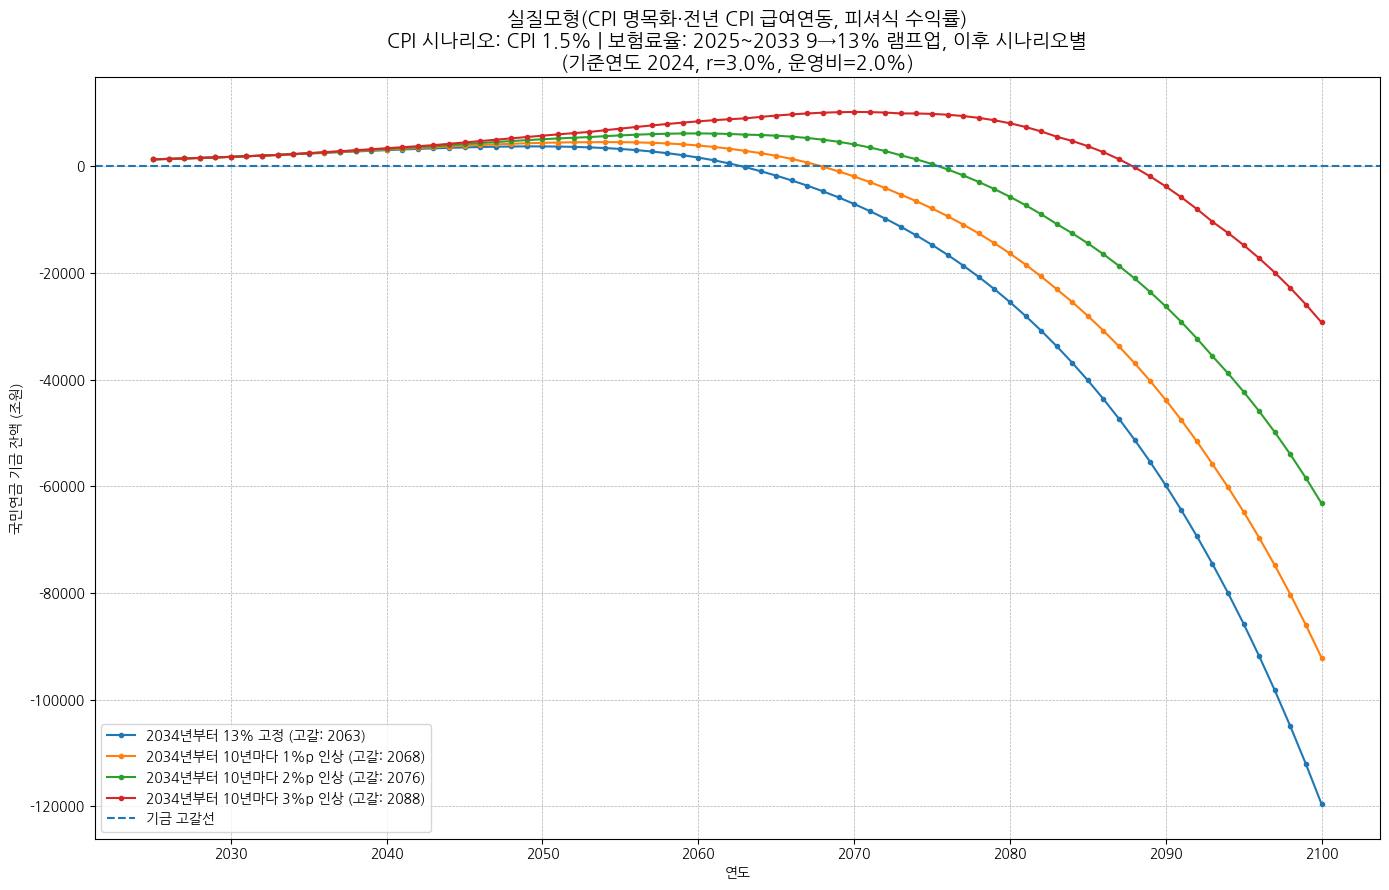

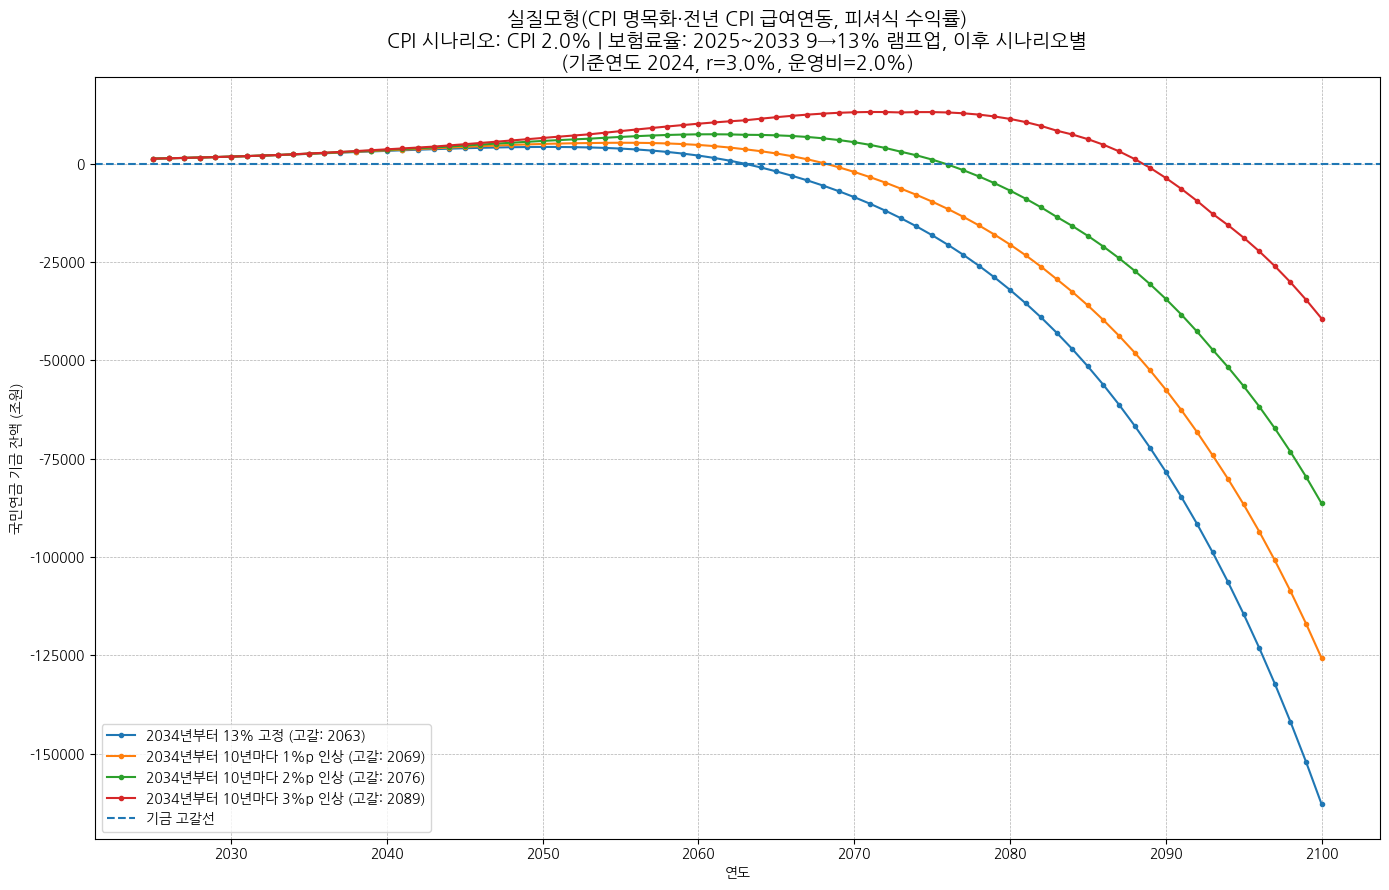

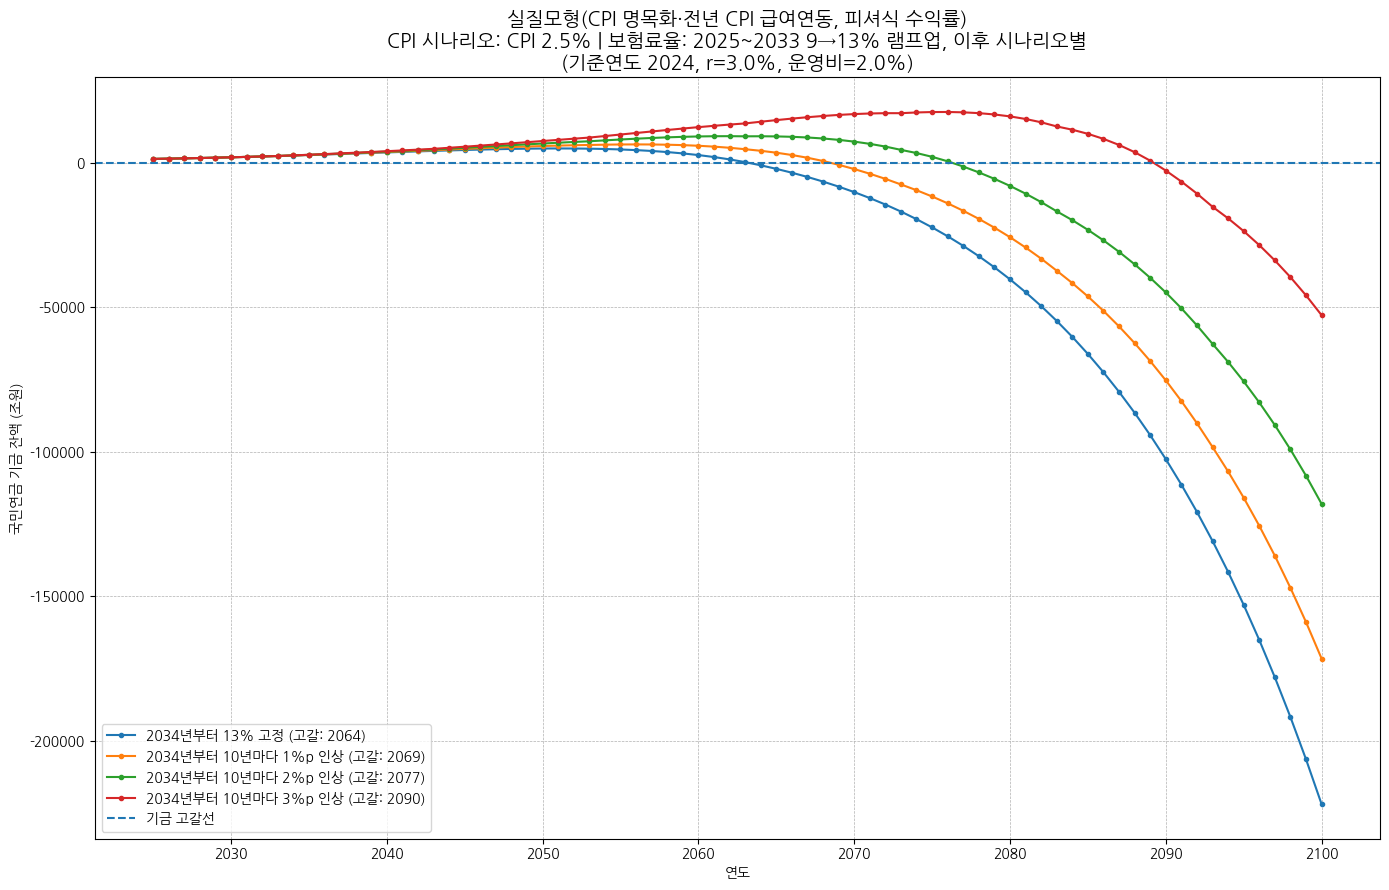

[기준연도] 2024
[2024년 기준 기금 잔액(명목)] 약 1,212.85 조원

[각 CPI × 보험료율 시나리오별 고갈 예상 연도]
CPI                   CPI 1.5%  CPI 2.0%  CPI 2.5%
보험료율 시나리오                                         
2034년부터 10년마다 1%p 인상      2068      2069      2069
2034년부터 10년마다 2%p 인상      2076      2076      2077
2034년부터 10년마다 3%p 인상      2088      2089      2090
2034년부터 13% 고정            2063      2063      2064

요약 CSV 저장: ./pension_exhaustion_summary.csv
시계열(롱) CSV 저장: ./pension_simulation_timeseries_long.csv
그래프 파일 저장:
 - ./pension_simulation_CPI_1.5pct.png
 - ./pension_simulation_CPI_2.0pct.png
 - ./pension_simulation_CPI_2.5pct.png


In [ ]:
# -*- coding: utf-8 -*-
"""
국민연금 기금 시뮬레이션 (보험료율 시나리오 × CPI 시나리오)
- 요청사항: CPI 3가지(1.5%, 2.0%, 2.5%)를 적용하여 2100년까지 고갈 시점 계산 및 그래프 작성
- 모델링: '실질 모형 + 피셔식' 적용
  1) df_combined의 '연금보험료/연금급여지급'을 2024년 가격 기준 '실질 경로'로 간주
  2) 명목 투자수익률은 피셔식으로 매년 변환: (1+i_t)=(1+r)*(1+π)
  3) 지급 중 연금의 물가연동: 전년도 CPI 반영(지출 명목화에 CPI_{t-1} 사용)
  4) 운영비 = 급여의 2% → 급여 명목화와 함께 자동 물가연동
- 참고: 원자료가 '명목'이라고 확신된다면 TREAT_SERIES_AS_REAL=False로 전환하면
  CPI는 투자수익률(피셔식)에만 반영되고, 보험료/급여에는 별도 곱하지 않습니다.
"""

# -----------------------------
# 0) 설정
# -----------------------------
DATA_PATHS = ["통계최강자전.csv", "./통계최강자전.csv"]  # 필요시 경로 추가
ENCODING = "utf-8-sig"

# 실질/명목 해석 스위치:
# True  → df_combined를 '실질(2024가격)'로 간주, CPI로 명목화
# False → df_combined를 '명목'으로 간주, CPI는 수익률(피셔식)에만 반영
TREAT_SERIES_AS_REAL = True

# 실질 투자수익률 r (연)
REAL_INVEST_RATE = 0.03

# 행정 규칙: 운영비율
ADMIN_RATE = 0.02

# 보험료율 베이스(상대 승수 산정용 분모, 9%→13% 램프업 등)
BASE_RATE = 9.0

# 출력 디렉토리
OUTPUT_DIR = "."

# -----------------------------
# (옵션) 한글 폰트 세팅 (환경에 한글 글꼴이 있을 때만)
# -----------------------------
def try_set_korean_font():
    """
    가능한 한글 폰트를 자동으로 설정. (없으면 그냥 넘어감)
    """
    from matplotlib import font_manager, rcParams
    candidates = [
        "Malgun Gothic",      # Windows
        "AppleGothic",        # macOS
        "NanumGothic",        # Linux (설치 시)
        "Noto Sans CJK KR",   # Google Noto
        "Noto Sans KR",
        "나눔고딕",
    ]
    available = {f.name for f in font_manager.fontManager.ttflist}
    for name in candidates:
        if name in available:
            rcParams["font.family"] = name
            rcParams["axes.unicode_minus"] = False
            return True
    # 폰트가 없어도 실행은 가능
    return False

try:
    try_set_korean_font()
except Exception:
    pass

# -----------------------------
# 1) 데이터 로드 및 전처리
# -----------------------------
def load_data():
    last_err = None
    for p in DATA_PATHS:
        try:
            df = pd.read_csv(p, encoding=ENCODING, index_col=0)
            df.index.name = "연도"
            try:
                df.index = df.index.astype(int)
            except Exception:
                df = (
                    df.rename_axis("연도")
                      .reset_index()
                      .rename(columns={df.columns[0]: "연도"})
                      .set_index("연도")
                )
                df.index = df.index.astype(int)
            return df
        except Exception as e:
            last_err = e
            continue
    raise FileNotFoundError(f"CSV 파일을 찾을 수 없습니다. 시도 경로: {DATA_PATHS}, 마지막 오류: {last_err}")

def clean_numeric_column(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace(" ", "", regex=False)
        .str.replace("\u00a0", "", regex=False)  # non‑breaking space
        .replace({"": np.nan})
        .astype(float)
    )

df_original = load_data()

# 필요한 컬럼 확인 및 클리닝
REQUIRED_COLS = ["연금보험료 (단위:억원)", "연금급여지급 (단위:억원)", "기금 운용 (단위:억원)"]
for col in REQUIRED_COLS:
    if col not in df_original.columns:
        raise KeyError(f"필수 컬럼이 없습니다: {col}")
    df_original[col] = clean_numeric_column(df_original[col])

# -----------------------------
# 2) 회귀 모델(간단형)로 실질(또는 명목 베이스) 경로 외삽
# -----------------------------
def fit_and_predict_future(x_hist, y_hist, degree, future_years):
    coef = np.polyfit(x_hist, y_hist, degree)
    poly_model = np.poly1d(coef)
    return poly_model(future_years)

last_year_in_data = int(df_original.index.max())
start_year_for_forecast = last_year_in_data + 1
END_YEAR = 2100
years_hist = df_original.index.values
future_years = np.arange(start_year_for_forecast, END_YEAR + 1)

predicted_income = np.maximum(
    0.0,
    fit_and_predict_future(
        years_hist,
        df_original["연금보험료 (단위:억원)"].values,
        2,
        future_years,
    ),
)
predicted_outgo = np.maximum(
    0.0,
    fit_and_predict_future(
        years_hist,
        df_original["연금급여지급 (단위:억원)"].values,
        3,
        future_years,
    ),
)

df_predicted = pd.DataFrame(
    {
        "연금보험료 (단위:억원)": predicted_income,
        "연금급여지급 (단위:억원)": predicted_outgo,
    },
    index=future_years,
)
df_predicted.index.name = "연도"

df_combined = pd.concat(
    [df_original[["연금보험료 (단위:억원)", "연금급여지급 (단위:억원)"]], df_predicted],
    axis=0,
).sort_index()

# -----------------------------
# 3) 보험료율 시나리오 (요청 코드 로직 유지)
# -----------------------------
def get_ramp_up_multiplier(yr):
    """2025~2033년 9%→13% 선형 증가 승수 (BASE_RATE 대비)."""
    target_rate = 13.0
    years_for_ramp_up = 2033 - 2024  # 9년 구간: 2025~2033
    current_rate = BASE_RATE + (target_rate - BASE_RATE) * (yr - 2024) / years_for_ramp_up
    return current_rate / BASE_RATE

def rate_scenario1_fn(yr):
    """2034년부터 13% 고정"""
    if yr <= 2033:
        return get_ramp_up_multiplier(yr)
    else:
        return 13.0 / BASE_RATE

def rate_scenario2_fn(yr):
    """2034년부터 10년마다 1%p 인상"""
    if yr <= 2033:
        return get_ramp_up_multiplier(yr)
    else:
        rate_at_2033 = 13.0
        decades_passed = (yr - 2034) // 10
        current_rate = rate_at_2033 + (decades_passed + 1) * 1.0
        return current_rate / BASE_RATE

def rate_scenario3_fn(yr):
    """2034년부터 10년마다 2%p 인상"""
    if yr <= 2033:
        return get_ramp_up_multiplier(yr)
    else:
        rate_at_2033 = 13.0
        decades_passed = (yr - 2034) // 10
        current_rate = rate_at_2033 + (decades_passed + 1) * 2.0
        return current_rate / BASE_RATE

def rate_scenario4_fn(yr):
    """2034년부터 10년마다 3%p 인상"""
    if yr <= 2033:
        return get_ramp_up_multiplier(yr)
    else:
        rate_at_2033 = 13.0
        decades_passed = (yr - 2034) // 10
        current_rate = rate_at_2033 + (decades_passed + 1) * 3.0
        return current_rate / BASE_RATE

SCENARIOS = [
    {"fn": rate_scenario1_fn, "label": "2034년부터 13% 고정"},
    {"fn": rate_scenario2_fn, "label": "2034년부터 10년마다 1%p 인상"},
    {"fn": rate_scenario3_fn, "label": "2034년부터 10년마다 2%p 인상"},
    {"fn": rate_scenario4_fn, "label": "2034년부터 10년마다 3%p 인상"},
]

# -----------------------------
# 4) CPI 유틸 & 피셔식
# -----------------------------
def build_cpi_index(series_years, base_year, annual_cpi_rate):
    """
    base_year의 지수=1.0, 이후는 (1+π)^누적.
    반환: dict {year: index}
    """
    idx = {}
    for y in series_years:
        if y <= base_year:
            idx[y] = 1.0
        else:
            steps = y - base_year
            idx[y] = (1.0 + annual_cpi_rate) ** steps
    return idx

def fisher_nominal_rate(real_rate, annual_cpi_rate):
    """피셔식: (1+i) = (1+r)*(1+π) - 1"""
    return (1.0 + real_rate) * (1.0 + annual_cpi_rate) - 1.0

# -----------------------------
# 5) 시뮬레이션 (실질모형 기본) with CPI
# -----------------------------
def simulate_with_cpi(
    data, base_balance_nominal, start_year, end_year, insurance_rate_fn,
    real_invest_rate=REAL_INVEST_RATE, admin_rate=ADMIN_RATE, cpi_rate=0.02,
    treat_series_as_real=TREAT_SERIES_AS_REAL, base_year_for_cpi=None
):
    """
    data: df_combined (연도 index)
    base_balance_nominal: 기준연도(마지막 관측연도) 명목 잔액 (억원)

    treat_series_as_real=True:
        data의 '보험료/급여'를 2024가격 실질로 해석 →
        income_nominal[t] = income_real[t] * CPI_t          (보험료/임금은 당해연도 CPI 반영)
        outgo_nominal[t]  = outgo_real[t]  * CPI_{t-1}       (지급 중 연금 전년도 CPI 반영)
    False:
        data를 명목 베이스로 해석 →
        income_nominal[t] = inc0 * rate_multiplier
        outgo_nominal[t]  = outgo0
        (CPI는 투자수익률 피셔식에만 반영)
    """
    if base_year_for_cpi is None:
        base_year_for_cpi = int(data.index.max()) if end_year <= data.index.max() else int(start_year - 1)

    years = np.arange(start_year, end_year + 1)
    cpi_index = build_cpi_index(np.arange(base_year_for_cpi, end_year + 1), base_year_for_cpi, cpi_rate)

    balance = float(base_balance_nominal)
    balances = []

    for yr in years:
        # 1) 투자수익 (명목)
        i_t = fisher_nominal_rate(real_invest_rate, cpi_rate)
        investment_return = balance * i_t if balance > 0 else 0.0
        balance += investment_return

        # 2) 수입·지출(명목)
        inc0 = float(data.loc[yr, "연금보험료 (단위:억원)"])
        outgo0 = float(data.loc[yr, "연금급여지급 (단위:억원)"])

        rate_multiplier = float(insurance_rate_fn(yr))

        if treat_series_as_real:
            # 실질 경로를 명목화
            income_nominal = inc0 * rate_multiplier * cpi_index[yr]           # 보험료/임금 = 당해 CPI
            outgo_nominal = outgo0 * cpi_index.get(yr - 1, 1.0)               # 급여 = 전년도 CPI
        else:
            # 명목 베이스 시나리오
            income_nominal = inc0 * rate_multiplier
            outgo_nominal = outgo0

        admin_cost = outgo_nominal * admin_rate

        # 3) 잔액 갱신
        balance += income_nominal - (outgo_nominal + admin_cost)
        balances.append(balance)

    df_result = pd.DataFrame({"연도": years, "잔액(억원)": balances})
    df_result["잔액(조원)"] = df_result["잔액(억원)"] / 10000.0
    return df_result

def find_exhaustion_year(df_fund: pd.DataFrame):
    neg_balance_years = df_fund[df_fund["잔액(억원)"] < 0]
    return int(neg_balance_years.iloc[0]["연도"]) if not neg_balance_years.empty else "고갈되지 않음"

# -----------------------------
# 6) 실행: CPI 3가지 × 보험료율 4가지
# -----------------------------
def main():
    base_balance_last = float(df_original.loc[last_year_in_data, "기금 운용 (단위:억원)"])
    START_YEAR = last_year_in_data + 1
    END_YEAR = 2100

    CPI_CASES = [
        {"label": "CPI 1.5%", "rate": 0.015},
        {"label": "CPI 2.0%", "rate": 0.020},
        {"label": "CPI 2.5%", "rate": 0.025},
    ]

    summary_rows = []
    long_records = []
    image_paths = []

    for cpi_case in CPI_CASES:
        cpi_label = cpi_case["label"]
        cpi_rate = cpi_case["rate"]

        plt.figure(figsize=(14, 9))

        for scenario in SCENARIOS:
            df_sim = simulate_with_cpi(
                df_combined,
                base_balance_last,
                START_YEAR,
                END_YEAR,
                insurance_rate_fn=scenario["fn"],
                real_invest_rate=REAL_INVEST_RATE,
                admin_rate=ADMIN_RATE,
                cpi_rate=cpi_rate,
                treat_series_as_real=TREAT_SERIES_AS_REAL,
                base_year_for_cpi=last_year_in_data,
            )
            ex_year = find_exhaustion_year(df_sim)

            summary_rows.append(
                {"CPI": cpi_label, "보험료율 시나리오": scenario["label"], "고갈 예상 연도": ex_year}
            )
            for _, r in df_sim.iterrows():
                long_records.append(
                    {
                        "CPI": cpi_label,
                        "보험료율 시나리오": scenario["label"],
                        "연도": int(r["연도"]),
                        "잔액(억원)": float(r["잔액(억원)"]),
                        "잔액(조원)": float(r["잔액(조원)"]),
                    }
                )

            label = f"{scenario['label']} (고갈: {ex_year})"
            plt.plot(df_sim["연도"], df_sim["잔액(조원)"], label=label, marker="o", markersize=3)

        plt.axhline(0, linestyle="--", linewidth=1.5, label="기금 고갈선")
        plt.xlabel("연도")
        plt.ylabel("국민연금 기금 잔액 (조원)")
        title_base = "실질모형(CPI 명목화·전년 CPI 급여연동, 피셔식 수익률)"
        title_suffix = "" if TREAT_SERIES_AS_REAL else " / 원자료 명목 가정(피셔식만 적용)"
        plt.title(
            f"{title_base}{title_suffix}\nCPI 시나리오: {cpi_label} | 보험료율: 2025~2033 9→13% 램프업, 이후 시나리오별\n(기준연도 {last_year_in_data}, r={REAL_INVEST_RATE*100:.1f}%, 운영비={ADMIN_RATE*100:.1f}%)",
            fontsize=14,
        )
        plt.legend()
        plt.grid(True, linestyle="--", linewidth=0.5)
        plt.tight_layout()

        img_name = f"pension_simulation_{cpi_label.replace(' ', '_').replace('%','pct')}.png"
        img_path = os.path.join(OUTPUT_DIR, img_name)
        plt.savefig(img_path, dpi=150)
        image_paths.append(img_path)
        plt.show()

    # 요약표 / 시계열
    df_summary = pd.DataFrame(summary_rows)
    df_pivot = df_summary.pivot(index="보험료율 시나리오", columns="CPI", values="고갈 예상 연도")
    df_long = pd.DataFrame(long_records)

    # 저장
    summary_csv_path = os.path.join(OUTPUT_DIR, "pension_exhaustion_summary.csv")
    long_csv_path = os.path.join(OUTPUT_DIR, "pension_simulation_timeseries_long.csv")
    df_pivot.to_csv(summary_csv_path, encoding="utf-8-sig")
    df_long.to_csv(long_csv_path, encoding="utf-8-sig", index=False)

    # 콘솔 출력
    print(f"[기준연도] {last_year_in_data}")
    print(f"[{last_year_in_data}년 기준 기금 잔액(명목)] 약 {base_balance_last/10000:,.2f} 조원\n")
    print("[각 CPI × 보험료율 시나리오별 고갈 예상 연도]")
    print(df_pivot)
    print(f"\n요약 CSV 저장: {summary_csv_path}")
    print(f"시계열(롱) CSV 저장: {long_csv_path}")
    print("그래프 파일 저장:")
    for p in image_paths:
        print(" -", p)

if __name__ == "__main__":
    try:
        main()
    except FileNotFoundError as e:
        print("오류:", e)
        print("CSV 파일이 스크립트와 같은 폴더에 있는지 확인하세요.")
        sys.exit(1)


#번외-사용한 변수 파일로 저장하는 코드

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np

# 1. CSV 파일 불러오기
df = pd.read_csv("통계최강자전.csv", encoding="utf-8-sig", index_col=0)
df.index.name = "연도"

# 2. 필요한 컬럼만 추출
df_extract = df[[
    "평균 연봉(단위: 만원, 만)",
    "국민연급 가입자 수 (명)",
    "국민연금 수급자 수 (명)",
    "연금보험료 (단위:억원)",
    "연금급여지급 (단위:억원)"
]].copy()

# 3. 쉼표 제거 후 숫자 변환
for col in ["국민연급 가입자 수 (명)", "국민연금 수급자 수 (명)", "연금보험료 (단위:억원)", "연금급여지급 (단위:억원)"]:
    df_extract[col] = df_extract[col].astype(str).str.replace(",", "").astype(float)

df_extract["평균 연봉(단위: 만원, 만)"] = df_extract["평균 연봉(단위: 만원, 만)"].astype(float)

# 4. 회귀모델로 2025~2075 예측
def fit_and_predict(x, y, degree, start_year=2025, end_year=2075):
    coef = np.polyfit(x, y, degree)
    poly = np.poly1d(coef)
    pred_years = np.arange(start_year, end_year+1)
    pred_values = poly(pred_years)
    return pd.Series(pred_values, index=pred_years)

years = df_extract.index.values.astype(int)

# 변수별 회귀 (차수는 앞서 설정한 것과 동일하게 적용)
pred_avg   = fit_and_predict(years, df_extract["평균 연봉(단위: 만원, 만)"], 1)
pred_contr = fit_and_predict(years, df_extract["국민연급 가입자 수 (명)"], 2)
pred_benef = fit_and_predict(years, df_extract["국민연금 수급자 수 (명)"], 2)
pred_inc   = fit_and_predict(years, df_extract["연금보험료 (단위:억원)"], 2)
pred_outgo = fit_and_predict(years, df_extract["연금급여지급 (단위:억원)"], 3)

# 5. 예측값 DataFrame으로 정리
df_pred = pd.DataFrame({
    "평균 연봉(단위: 만원, 만)": pred_avg.round(2),
    "국민연급 가입자 수 (명)": pred_contr.round(0),
    "국민연금 수급자 수 (명)": pred_benef.round(0),
    "연금보험료 (단위:억원)": pred_inc.round(0),
    "연금급여지급 (단위:억원)": pred_outgo.round(0)
})

# 6. 실제+예측 데이터 합치기
df_final = pd.concat([df_extract, df_pred])

# 7. 엑셀 저장
output_file = "국민연금_실측+예측(2000~2075).xlsx"
df_final.to_excel(output_file, sheet_name="실측+예측")  # encoding 제거

print(f"엑셀 파일 저장 완료: {output_file}")


엑셀 파일 저장 완료: 국민연금_실측+예측(2000~2075).xlsx
